# 🛡️ HUẤN LUYỆN MÔ HÌNH — HỆ THỐNG PHÁT HIỆN MÁY CHỦ C&C

**Đề tài:** Hệ thống Phát hiện Máy chủ C&C sử dụng Phân tích Đa lớp và Trí tuệ Nhân tạo  
**Nhóm thực hiện:** Huỳnh Quốc Khải, Nguyễn Hữu Hoàng, Vũ Thị Thu Trang — Lớp B5D13/B6D13  
**GVHD:** Đại úy TS. Tống Anh Tuấn  

---

## Mục đích notebook này

Notebook này thực hiện **toàn bộ quy trình huấn luyện** hai mô hình AI cốt lõi của hệ thống:

| Mô hình | Bộ dữ liệu | Mục tiêu | File output |
|---|---|---|---|
| **XGBoost** | CTU-13 + CICIDS2017 | Phân loại luồng mạng (Benign vs C&C Botnet) | `cnc-detector/models/xgboost_flow_model.joblib` + `flow_scaler.joblib` |
| **Bi-LSTM** | Alexa Top 1M + Bambenek DGA | Phát hiện tên miền DGA | `cnc-detector/models/bilstm_dga_model.keras` + `char_map.npy` |

Kết quả từ notebook này **được sao chép vào Mục 3.2.6** của báo cáo khoa học.

---

## Cấu trúc notebook

```
Section 0 — Cài đặt và kiểm tra môi trường (Windows + Linux)
Section 1 — Tải và khám phá dữ liệu XGBoost (CTU-13 + CICIDS2017)
Section 2 — Tiền xử lý dữ liệu XGBoost
Section 3 — Huấn luyện và đánh giá mô hình XGBoost
Section 4 — Lưu model XGBoost
Section 5 — Tải và tiền xử lý dữ liệu DGA (Bi-LSTM)
Section 6 — Xây dựng và huấn luyện mô hình Bi-LSTM
Section 7 — Đánh giá mô hình Bi-LSTM
Section 8 — Lưu model Bi-LSTM
Section 9 — Tổng kết và bảng kết quả cho báo cáo
```

---

## ⚙️ Hỗ trợ đa nền tảng: Windows & Linux

> Notebook này được thiết kế để chạy trên **cả Windows và Linux** mà không cần chỉnh sửa.

| Thành phần | Windows 10/11 | Linux (Ubuntu 20.04+) |
|---|---|---|
| **Notebook huấn luyện** | ✅ Đầy đủ | ✅ Đầy đủ |
| **XGBoost training** | ✅ CPU | ✅ CPU |
| **Bi-LSTM / TensorFlow** | ✅ CPU (cần AVX) | ✅ CPU / GPU (khuyến nghị) |
| **GUI phát hiện** (`main.py`) | ✅ Đầy đủ | ⚠️ Hạn chế (thiếu Npcap/psutil Windows API) |
| **Phân tích PCAP** | ✅ | ✅ |

### Cài đặt nhanh theo OS

**Windows (PowerShell — quyền Administrator):**
```powershell
python -m venv .venv
.venv\Scripts\Activate.ps1
pip install -r requirements.txt
jupyter notebook train_models.ipynb
```

**Linux / Ubuntu (bash):**
```bash
sudo apt install libpcap-dev python3-dev python3-venv -y
python3 -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt
# Nếu có GPU NVIDIA: pip install tensorflow[and-cuda]
jupyter notebook train_models.ipynb
# Headless server: jupyter notebook --no-browser --port=8888
```

---
## Section 0: Cài đặt và kiểm tra môi trường

In [2]:
# ============================================================
# 0.0 — Phát hiện hệ điều hành và kiểm tra cross-platform
# ============================================================
import sys
import platform
import os
import subprocess
from pathlib import Path

OS_NAME    = platform.system()   # 'Windows', 'Linux', 'Darwin'
OS_RELEASE = platform.release()
ARCH       = platform.machine()
IS_WINDOWS = OS_NAME == 'Windows'
IS_LINUX   = OS_NAME == 'Linux'
IS_MACOS   = OS_NAME == 'Darwin'

print('=' * 60)
print('  THÔNG TIN MÔI TRƯỜNG THỰC NGHIỆM')
print('=' * 60)
print(f'  Hệ điều hành  : {OS_NAME} {OS_RELEASE} ({ARCH})')
print(f'  Python        : {sys.version.split()[0]}')
print(f'  Thực thi tại  : {sys.executable}')
print()

# --- Kiểm tra AVX (bắt buộc cho TensorFlow) ---
def check_avx_support() -> bool:
    """Kiểm tra CPU có hỗ trợ AVX instruction set không."""
    if IS_WINDOWS:
        try:
            import ctypes
            # PF_AVX_INSTRUCTIONS_AVAILABLE = 17 (Windows API constant)
            return bool(ctypes.windll.kernel32.IsProcessorFeaturePresent(17))
        except Exception:
            return False
    elif IS_LINUX:
        try:
            with open('/proc/cpuinfo', 'r') as f:
                return 'avx' in f.read().lower()
        except Exception:
            return False
    else:  # macOS
        try:
            result = subprocess.run(
                ['sysctl', '-n', 'hw.optional.avx1_0'],
                capture_output=True, text=True
            )
            return result.stdout.strip() == '1'
        except Exception:
            return True  # Assume Apple Silicon supports NEON (equivalent)

# --- Kiểm tra GPU ---
def check_gpu() -> str:
    """Phát hiện GPU NVIDIA qua nvidia-smi (Windows + Linux)."""
    try:
        result = subprocess.run(
            ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
            capture_output=True, text=True, timeout=5
        )
        gpus = [g.strip() for g in result.stdout.strip().splitlines() if g.strip()]
        return ' | '.join(gpus) if gpus else 'Không tìm thấy GPU NVIDIA'
    except Exception:
        return 'nvidia-smi không khả dụng — CPU only mode'

AVX_SUPPORTED = check_avx_support()
GPU_INFO      = check_gpu()

print(f'  AVX support   : {"✅ Có" if AVX_SUPPORTED else "❌ Không — TensorFlow sẽ dùng heuristic fallback"}')
print(f'  GPU           : {GPU_INFO}')
print()

# --- Kiểm tra gói phụ thuộc hệ thống (Linux only) ---
if IS_LINUX:
    print('  📋 Kiểm tra gói hệ thống (Linux):')
    system_deps = {
        'libpcap-dev'    : 'dpkg -s libpcap-dev',       # Scapy cần để bắt gói tin
        'python3-dev'    : 'dpkg -s python3-dev',        # Compiler cho native extensions
        'build-essential': 'dpkg -s build-essential',    # GCC/G++ cho XGBoost
    }
    for pkg, cmd in system_deps.items():
        try:
            result = subprocess.run(cmd.split(), capture_output=True, text=True)
            status = '✅' if result.returncode == 0 else f'❌ Thiếu → sudo apt install {pkg}'
        except Exception:
            status = '⚠️ Không kiểm tra được'
        print(f'     {pkg:<20}: {status}')
    print()

# --- Ghi chú đặc thù theo OS ---
if IS_WINDOWS:
    print('  💡 Windows notes:')
    print('     ✓ Notebook này KHÔNG cần Npcap (chỉ cần cho main.py)')
    print('     ✓ TensorFlow AVX warning trên CPU cũ là bình thường')
    print('     ✓ Đường dẫn dùng pathlib.Path — tương thích backslash tự động')
    print('     ✓ Để cài TF GPU trên Windows: cần CUDA Toolkit 11.8 + cuDNN 8.6 thủ công')
elif IS_LINUX:
    print('  💡 Linux notes:')
    print('     ✓ Training Bi-LSTM nhanh hơn đáng kể nếu có GPU + CUDA')
    print('     ✓ Cài TF GPU: pip install tensorflow[and-cuda]  (TF 2.15+)')
    print('     ✓ Jupyter headless: jupyter notebook --no-browser --port=8888')
    print('     ✓ Matplotlib headless: matplotlib.use("Agg") — sẽ tự động bật bên dưới')

print('=' * 60)

  THÔNG TIN MÔI TRƯỜNG THỰC NGHIỆM
  Hệ điều hành  : Windows 10 (AMD64)
  Python        : 3.11.9
  Thực thi tại  : e:\Programs\Python 3.11\python.exe

  AVX support   : ✅ Có
  GPU           : NVIDIA GeForce RTX 3050 Ti Laptop GPU, 4096 MiB

  💡 Windows notes:
     ✓ Notebook này KHÔNG cần Npcap (chỉ cần cho main.py)
     ✓ TensorFlow AVX warning trên CPU cũ là bình thường
     ✓ Đường dẫn dùng pathlib.Path — tương thích backslash tự động
     ✓ Để cài TF GPU trên Windows: cần CUDA Toolkit 11.8 + cuDNN 8.6 thủ công


In [3]:
# ============================================================
# 0.1 — Cài đặt thư viện Python (cross-platform)
# ============================================================
# Bỏ comment dòng tương ứng với OS của bạn:

# --- Windows & Linux (CPU only) ---
# !pip install xgboost scikit-learn numpy pandas matplotlib seaborn joblib tqdm tensorflow

# --- Linux với GPU NVIDIA (khuyến nghị cho Bi-LSTM) ---
# !pip install xgboost scikit-learn numpy pandas matplotlib seaborn joblib tqdm
# !pip install tensorflow[and-cuda]   # TF 2.15+ tích hợp CUDA tự động

# --- Jupyter kernel hiển thị matplotlib trên Linux headless ---
# import matplotlib
# matplotlib.use('Agg')  # Bỏ comment nếu chạy trên server không có màn hình

print(f'Python {sys.version.split()[0]} | OS: {OS_NAME} | Môi trường sẵn sàng')

Python 3.11.9 | OS: Windows | Môi trường sẵn sàng


In [4]:
# ============================================================
# 0.2 — Import toàn bộ thư viện cần thiết
# ============================================================
import time
import hashlib
import warnings
import math
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Matplotlib backend tự động theo OS
import matplotlib
if IS_LINUX:
    # Kiểm tra display server có tồn tại không
    has_display = bool(os.environ.get('DISPLAY') or os.environ.get('WAYLAND_DISPLAY'))
    if not has_display:
        print('[INFO] Linux headless mode — dùng Agg backend cho matplotlib')
        matplotlib.use('Agg')
    else:
        print('[INFO] Linux desktop mode — dùng interactive backend')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
from tqdm import tqdm

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, roc_auc_score, precision_score, recall_score,
    matthews_corrcoef, ConfusionMatrixDisplay
)

# XGBoost
import xgboost as xgb
from xgboost import XGBClassifier

# Style
plt.style.use('dark_background')
sns.set_palette('husl')
ACCENT  = '#38bdf8'   # xanh nước
DANGER  = '#ef4444'   # đỏ
SUCCESS = '#22c55e'   # xanh lá
WARNING = '#f59e0b'   # vàng

print(f'XGBoost version : {xgb.__version__}')
print(f'NumPy version   : {np.__version__}')
print(f'Pandas version  : {pd.__version__}')
print(f'Matplotlib backend: {matplotlib.get_backend()}')

XGBoost version : 3.2.0
NumPy version   : 2.4.6
Pandas version  : 3.0.3
Matplotlib backend: module://matplotlib_inline.backend_inline


In [5]:
# ============================================================
# 0.3 — Kiểm tra TensorFlow (cross-platform)
# ============================================================
try:
    import tensorflow as tf
    print(f'TensorFlow version : {tf.__version__}')
    gpu_list = tf.config.list_physical_devices('GPU')
    print(f'GPU devices (TF)   : {[g.name for g in gpu_list] if gpu_list else "None — CPU mode"}')
    
    if IS_LINUX and gpu_list:
        # Bật memory growth để tránh OOM trên Linux
        for gpu in gpu_list:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('[Linux] GPU memory growth enabled')
    
    TF_AVAILABLE = True
except ImportError as e:
    print(f'[WARN] TensorFlow không khả dụng: {e}')
    if IS_WINDOWS:
        print('[HINT] Windows: pip install tensorflow')
        if not AVX_SUPPORTED:
            print('[HINT] CPU thiếu AVX — dùng tensorflow-cpu hoặc chế độ heuristic-only')
    elif IS_LINUX:
        print('[HINT] Linux CPU: pip install tensorflow')
        print('[HINT] Linux GPU: pip install tensorflow[and-cuda]')
    TF_AVAILABLE = False

TensorFlow version : 2.21.0
GPU devices (TF)   : None — CPU mode


In [6]:
# ============================================================
# 0.4 — Cấu hình đường dẫn project (cross-platform)
# ============================================================
# pathlib.Path tự động xử lý '\' (Windows) và '/' (Linux/macOS)
NOTEBOOK_DIR   = Path().resolve()
PROJECT_ROOT   = NOTEBOOK_DIR  # train_models.ipynb nằm ở thư mục gốc u_a_u_o/
CNC_DIR        = PROJECT_ROOT / 'cnc-detector'
MODELS_DIR     = CNC_DIR / 'models'
DATA_DIR       = CNC_DIR / 'data'
TRAIN_DATA_DIR = PROJECT_ROOT / 'train_data'
CTU13_DIR      = TRAIN_DATA_DIR / 'ctu13'
CICIDS_DIR     = TRAIN_DATA_DIR / 'cicids2017'
DGA_DIR        = TRAIN_DATA_DIR / 'dga'

# Tạo thư mục nếu chưa có
for d in [MODELS_DIR, TRAIN_DATA_DIR, CTU13_DIR, CICIDS_DIR, DGA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Kiểm tra quyền ghi (quan trọng trên Linux nếu không dùng sudo)
def check_write_permission(path: Path) -> bool:
    test_file = path / '.write_test'
    try:
        test_file.touch()
        test_file.unlink()
        return True
    except PermissionError:
        return False

print('📁 Cấu trúc thư mục:')
print(f'   PROJECT_ROOT  : {PROJECT_ROOT}')
print(f'   MODELS_DIR    : {MODELS_DIR}')
print(f'   TRAIN_DATA_DIR: {TRAIN_DATA_DIR}')
print()

# Kiểm tra quyền ghi
can_write = check_write_permission(MODELS_DIR)
print(f'   Quyền ghi models/ : {"✅ OK" if can_write else "❌ Lỗi — Linux: kiểm tra chmod/ownership"}')
print()

print('📋 Hướng dẫn đặt dữ liệu:')
print(f'   CTU-13 CSV   → {CTU13_DIR}/')
print(f'   CICIDS2017   → {CICIDS_DIR}/')
print(f'   DGA domains  → {DGA_DIR}/dga_domains.txt    (1 domain/dòng, label=1)')
print(f'   Benign       → {DGA_DIR}/benign_domains.txt (1 domain/dòng, label=0)')
print()

# Separator theo OS để dùng trong lệnh shell nếu cần
PATH_SEP = '\\' if IS_WINDOWS else '/'
print(f'   Path separator: "{PATH_SEP}" ({OS_NAME})')

📁 Cấu trúc thư mục:
   PROJECT_ROOT  : E:\u_a_u_o
   MODELS_DIR    : E:\u_a_u_o\cnc-detector\models
   TRAIN_DATA_DIR: E:\u_a_u_o\train_data

   Quyền ghi models/ : ✅ OK

📋 Hướng dẫn đặt dữ liệu:
   CTU-13 CSV   → E:\u_a_u_o\train_data\ctu13/
   CICIDS2017   → E:\u_a_u_o\train_data\cicids2017/
   DGA domains  → E:\u_a_u_o\train_data\dga/dga_domains.txt    (1 domain/dòng, label=1)
   Benign       → E:\u_a_u_o\train_data\dga/benign_domains.txt (1 domain/dòng, label=0)

   Path separator: "\" (Windows)


In [7]:
# ============================================================
# 0.5 — Hằng số toàn cục (nhất quán với cnc-detector/modules/)
# ============================================================
# Phải khớp TUYỆT ĐỐI với flow_analyzer.py — FLOW_FEATURES
FLOW_FEATURES = [
    'flow_duration', 'total_fwd_packets', 'total_bwd_packets',
    'fwd_packet_length_mean', 'bwd_packet_length_mean',
    'flow_bytes_per_sec', 'flow_packets_per_sec',
    'flow_iat_mean', 'flow_iat_std', 'flow_iat_max', 'flow_iat_min',
    'fwd_iat_mean', 'fwd_iat_std', 'bwd_iat_mean',
    'fwd_psh_flags', 'bwd_psh_flags',
    'fwd_header_length', 'bwd_header_length',
    'fwd_packets_per_sec', 'bwd_packets_per_sec',
    'min_packet_length', 'max_packet_length',
    'packet_length_mean', 'packet_length_std', 'packet_length_variance',
    'fin_flag_count', 'syn_flag_count', 'rst_flag_count',
    'ack_flag_count', 'urg_flag_count',
    'avg_fwd_segment_size', 'avg_bwd_segment_size',
    'active_mean', 'idle_mean',
]

# Phải khớp với dga_detector.py — VALID_CHARS, MAX_LEN
VALID_CHARS = list('abcdefghijklmnopqrstuvwxyz0123456789-.')
MAX_LEN = 64

# Nhãn CICIDS2017 cho các nhãn C&C/Botnet
BOTNET_LABELS = ['Bot', 'BOTNET', 'Botnet', 'C&C', 'C2']
BENIGN_LABELS = ['BENIGN', 'Benign', 'benign']

# Ánh xạ tên cột CICIDS2017 → tên trong FLOW_FEATURES
CICIDS_COLUMN_MAP = {
    'Flow Duration'          : 'flow_duration',
    'Total Fwd Packets'      : 'total_fwd_packets',
    'Total Backward Packets' : 'total_bwd_packets',
    'Fwd Packet Length Mean' : 'fwd_packet_length_mean',
    'Bwd Packet Length Mean' : 'bwd_packet_length_mean',
    'Flow Bytes/s'           : 'flow_bytes_per_sec',
    'Flow Packets/s'         : 'flow_packets_per_sec',
    'Flow IAT Mean'          : 'flow_iat_mean',
    'Flow IAT Std'           : 'flow_iat_std',
    'Flow IAT Max'           : 'flow_iat_max',
    'Flow IAT Min'           : 'flow_iat_min',
    'Fwd IAT Mean'           : 'fwd_iat_mean',
    'Fwd IAT Std'            : 'fwd_iat_std',
    'Bwd IAT Mean'           : 'bwd_iat_mean',
    'Fwd PSH Flags'          : 'fwd_psh_flags',
    'Bwd PSH Flags'          : 'bwd_psh_flags',
    'Fwd Header Length'      : 'fwd_header_length',
    'Bwd Header Length'      : 'bwd_header_length',
    'Fwd Packets/s'          : 'fwd_packets_per_sec',
    'Bwd Packets/s'          : 'bwd_packets_per_sec',
    'Min Packet Length'      : 'min_packet_length',
    'Max Packet Length'      : 'max_packet_length',
    'Packet Length Mean'     : 'packet_length_mean',
    'Packet Length Std'      : 'packet_length_std',
    'Packet Length Variance' : 'packet_length_variance',
    'FIN Flag Count'         : 'fin_flag_count',
    'SYN Flag Count'         : 'syn_flag_count',
    'RST Flag Count'         : 'rst_flag_count',
    'ACK Flag Count'         : 'ack_flag_count',
    'URG Flag Count'         : 'urg_flag_count',
    'Average Packet Size'    : 'packet_length_mean',   # fallback alias
    'Avg Fwd Segment Size'   : 'avg_fwd_segment_size',
    'Avg Bwd Segment Size'   : 'avg_bwd_segment_size',
    'Active Mean'            : 'active_mean',
    'Idle Mean'              : 'idle_mean',
}

print(f'✅ {len(FLOW_FEATURES)} đặc trưng XGBoost được định nghĩa')
print(f'✅ {len(VALID_CHARS)} ký tự trong VALID_CHARS cho Bi-LSTM')
print(f'✅ MAX_LEN = {MAX_LEN}')

✅ 34 đặc trưng XGBoost được định nghĩa
✅ 38 ký tự trong VALID_CHARS cho Bi-LSTM
✅ MAX_LEN = 64


---
## Section 1: Tải và khám phá dữ liệu XGBoost

In [8]:
# ============================================================
# 1.1 — Hàm tải dữ liệu CTU-13 và CICIDS2017
# ============================================================
def load_ctu13(data_dir: Path) -> pd.DataFrame:
    """
    Tải dữ liệu CTU-13 từ các file NetFlow CSV.
    Download: https://www.stratosphereips.org/datasets-ctu13
    
    Cấu trúc file:
      StartTime, Dur, Proto, SrcAddr, Sport, Dir, DstAddr, Dport,
      State, sTos, dTos, TotPkts, TotBytes, SrcBytes, Label
    """
    csv_files = list(data_dir.glob('*.csv')) + list(data_dir.glob('*.binetflow'))
    if not csv_files:
        print(f'[INFO] Không tìm thấy file CSV trong {data_dir}')
        return pd.DataFrame()
    dfs = []
    for f in csv_files:
        try:
            df = pd.read_csv(f, low_memory=False)
            df.columns = df.columns.str.strip()
            dfs.append(df)
            print(f'  Loaded: {f.name} — {len(df):,} rows')
        except Exception as e:
            print(f'  [WARN] {f.name}: {e}')
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


def load_cicids2017(data_dir: Path) -> pd.DataFrame:
    """
    Tải dữ liệu CICIDS2017 từ các file CSV (CICFlowMeter output).
    Download: https://www.unb.ca/cic/datasets/ids-2017.html
    File quan trọng: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv (có nhãn Bot)
    """
    csv_files = list(data_dir.glob('*.csv'))
    if not csv_files:
        print(f'[INFO] Không tìm thấy file CSV trong {data_dir}')
        return pd.DataFrame()
    dfs = []
    for f in csv_files:
        try:
            df = pd.read_csv(f, low_memory=False)
            df.columns = df.columns.str.strip()
            dfs.append(df)
            print(f'  Loaded: {f.name} — {len(df):,} rows')
        except Exception as e:
            print(f'  [WARN] {f.name}: {e}')
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


print('📂 Đang tải dữ liệu CTU-13...')
df_ctu = load_ctu13(CTU13_DIR)

print('\n📂 Đang tải dữ liệu CICIDS2017...')
df_cic = load_cicids2017(CICIDS_DIR)

print(f'\n📊 CTU-13    : {len(df_ctu):,} dòng, {len(df_ctu.columns)} cột')
print(f'📊 CICIDS2017: {len(df_cic):,} dòng, {len(df_cic.columns)} cột')

📂 Đang tải dữ liệu CTU-13...
[INFO] Không tìm thấy file CSV trong E:\u_a_u_o\train_data\ctu13

📂 Đang tải dữ liệu CICIDS2017...
  Loaded: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv — 225,745 rows
  Loaded: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv — 286,467 rows
  Loaded: Friday-WorkingHours-Morning.pcap_ISCX.csv — 191,033 rows
  Loaded: Monday-WorkingHours.pcap_ISCX.csv — 529,918 rows
  Loaded: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv — 288,602 rows
  Loaded: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv — 170,366 rows
  Loaded: Tuesday-WorkingHours.pcap_ISCX.csv — 445,909 rows
  Loaded: Wednesday-workingHours.pcap_ISCX.csv — 692,703 rows

📊 CTU-13    : 0 dòng, 0 cột
📊 CICIDS2017: 2,830,743 dòng, 79 cột


In [9]:
# ============================================================
# 1.2 — Khám phá phân bố nhãn
# ============================================================
def show_label_distribution(df: pd.DataFrame, label_col: str, title: str):
    """Hiển thị phân bố nhãn."""
    if df.empty or label_col not in df.columns:
        print(f'[SKIP] DataFrame rỗng hoặc không có cột "{label_col}"')
        return
    counts = df[label_col].value_counts()
    print(f'\n{"="*50}\n  {title}\n{"="*50}')
    for label, count in counts.items():
        pct = count / len(df) * 100
        bar = '█' * int(pct / 2)
        print(f'  {str(label):<30} {count:>8,}  ({pct:5.1f}%)  {bar}')

if not df_ctu.empty:
    label_col_ctu = next((c for c in df_ctu.columns if 'label' in c.lower()), None)
    if label_col_ctu:
        show_label_distribution(df_ctu, label_col_ctu, 'CTU-13 — Phân bố nhãn')

if not df_cic.empty:
    label_col_cic = next((c for c in df_cic.columns if 'label' in c.lower()), 'Label')
    show_label_distribution(df_cic, label_col_cic, 'CICIDS2017 — Phân bố nhãn')


  CICIDS2017 — Phân bố nhãn
  BENIGN                         2,273,097  ( 80.3%)  ████████████████████████████████████████
  DoS Hulk                        231,073  (  8.2%)  ████
  PortScan                        158,930  (  5.6%)  ██
  DDoS                            128,027  (  4.5%)  ██
  DoS GoldenEye                    10,293  (  0.4%)  
  FTP-Patator                       7,938  (  0.3%)  
  SSH-Patator                       5,897  (  0.2%)  
  DoS slowloris                     5,796  (  0.2%)  
  DoS Slowhttptest                  5,499  (  0.2%)  
  Bot                               1,966  (  0.1%)  
  Web Attack � Brute Force          1,507  (  0.1%)  
  Web Attack � XSS                    652  (  0.0%)  
  Infiltration                         36  (  0.0%)  
  Web Attack � Sql Injection           21  (  0.0%)  
  Heartbleed                           11  (  0.0%)  


In [10]:
# ============================================================
# 1.3 — Tạo dữ liệu demo nếu không có file thực
# ============================================================
USE_SYNTHETIC = df_ctu.empty and df_cic.empty

if USE_SYNTHETIC:
    print('[INFO] Không tìm thấy dữ liệu thực — sử dụng synthetic data để demo')
    print('[INFO] Đặt file CSV thực vào:')
    print(f'       CTU-13:     {CTU13_DIR}')
    print(f'       CICIDS2017: {CICIDS_DIR}')

    np.random.seed(42)
    N_BENIGN = 5000
    N_BOTNET = 500

    benign_data = {feat: np.abs(np.random.normal(0, 1, N_BENIGN)) for feat in FLOW_FEATURES}
    benign_data.update({
        'flow_duration'         : np.abs(np.random.normal(50000, 30000, N_BENIGN)),
        'flow_iat_mean'         : np.abs(np.random.normal(200, 150, N_BENIGN)),
        'flow_iat_std'          : np.abs(np.random.normal(300, 200, N_BENIGN)),
        'active_mean'           : np.abs(np.random.normal(800, 400, N_BENIGN)),
        'idle_mean'             : np.abs(np.random.normal(200, 100, N_BENIGN)),
        'fwd_packet_length_mean': np.abs(np.random.normal(700, 300, N_BENIGN)),
        'flow_bytes_per_sec'    : np.abs(np.random.normal(50000, 30000, N_BENIGN)),
    })

    botnet_data = {feat: np.abs(np.random.normal(0, 0.3, N_BOTNET)) for feat in FLOW_FEATURES}
    botnet_data.update({
        'flow_duration'         : np.abs(np.random.normal(300000, 5000, N_BOTNET)),
        'flow_iat_mean'         : np.abs(np.random.normal(60000, 500, N_BOTNET)),   # Đều đặn
        'flow_iat_std'          : np.abs(np.random.normal(100, 30, N_BOTNET)),       # Nhỏ
        'active_mean'           : np.abs(np.random.normal(15, 5, N_BOTNET)),         # Hoạt động ngắn
        'idle_mean'             : np.abs(np.random.normal(60000, 1000, N_BOTNET)),   # Ngủ dài
        'fwd_packet_length_mean': np.abs(np.random.normal(80, 20, N_BOTNET)),
        'flow_bytes_per_sec'    : np.abs(np.random.normal(50, 20, N_BOTNET)),
    })

    df_b = pd.DataFrame(benign_data); df_b['label'] = 0
    df_m = pd.DataFrame(botnet_data); df_m['label'] = 1
    df_synthetic = pd.concat([df_b, df_m]).sample(frac=1, random_state=42).reset_index(drop=True)

    print(f'\n✅ Synthetic: {N_BENIGN:,} Benign + {N_BOTNET:,} Botnet = {N_BENIGN+N_BOTNET:,} samples')
    print(f'   Tỷ lệ imbalance: {N_BENIGN/N_BOTNET:.1f}:1')
else:
    print('✅ Dữ liệu thực tế đã được tải. Tiếp tục xử lý...')

✅ Dữ liệu thực tế đã được tải. Tiếp tục xử lý...


---
## Section 2: Tiền xử lý dữ liệu XGBoost

In [11]:
# ============================================================
# 2.1 — Hàm chuẩn hóa và chọn đặc trưng từ CICIDS2017
# ============================================================
def preprocess_cicids(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty: return pd.DataFrame()
    df = df.copy().rename(columns=CICIDS_COLUMN_MAP)
    # Xóa cột trùng tên do alias trong CICIDS_COLUMN_MAP
    # (vd: Packet Length Mean và Average Packet Size cùng → packet_length_mean)
    df = df.loc[:, ~df.columns.duplicated()]
    label_col = next((c for c in df.columns if 'label' in c.lower()), None)
    if label_col is None: raise ValueError('Không tìm thấy cột nhãn')
    mask = df[label_col].isin(BOTNET_LABELS + BENIGN_LABELS)
    df = df[mask].copy()
    df['label'] = df[label_col].apply(lambda x: 1 if str(x).strip() in BOTNET_LABELS else 0)
    for f in FLOW_FEATURES:
        if f not in df.columns:
            df[f] = 0.0
    df[FLOW_FEATURES] = df[FLOW_FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0)
    return df[FLOW_FEATURES + ['label']]


if USE_SYNTHETIC:
    df_processed = df_synthetic.copy()
    print('[INFO] Sử dụng synthetic data')
else:
    dfs_ready = []
    if not df_cic.empty:
        print('⚙️ Xử lý CICIDS2017...')
        df_cic_proc = preprocess_cicids(df_cic)
        dfs_ready.append(df_cic_proc)
        print(f'   → {len(df_cic_proc):,} rows sau lọc')
    if not df_ctu.empty:
        print('⚙️ Xử lý CTU-13...')
        label_col = next((c for c in df_ctu.columns if 'label' in c.lower()), None)
        if label_col:
            df_ctu_sub = df_ctu.copy()
            df_ctu_sub['label'] = df_ctu_sub[label_col].apply(
                lambda x: 1 if any(b.lower() in str(x).lower() for b in ['botnet','bot','c&c']) else 0
            )
            for f in FLOW_FEATURES:
                if f not in df_ctu_sub.columns: df_ctu_sub[f] = 0.0
            df_ctu_sub[FLOW_FEATURES] = df_ctu_sub[FLOW_FEATURES].replace([np.inf,-np.inf], np.nan).fillna(0)
            dfs_ready.append(df_ctu_sub[FLOW_FEATURES + ['label']])
            print(f'   → {len(df_ctu_sub):,} rows')
    df_processed = pd.concat(dfs_ready, ignore_index=True) if dfs_ready else pd.DataFrame()

print(f'\n📊 Dataset cuối: {len(df_processed):,} samples')
if not df_processed.empty:
    vc = df_processed['label'].value_counts()
    n_benign = vc.get(0, 0); n_botnet = vc.get(1, 0)
    print(f'   BENIGN : {n_benign:,} ({n_benign/len(df_processed)*100:.1f}%)')
    print(f'   BOTNET : {n_botnet:,} ({n_botnet/len(df_processed)*100:.1f}%)')
    SCALE_POS_WEIGHT = n_benign / n_botnet if n_botnet > 0 else 1.0
    print(f'   scale_pos_weight = {SCALE_POS_WEIGHT:.2f}')

⚙️ Xử lý CICIDS2017...
   → 2,275,063 rows sau lọc

📊 Dataset cuối: 2,275,063 samples
   BENIGN : 2,273,097 (99.9%)
   BOTNET : 1,966 (0.1%)
   scale_pos_weight = 1156.20


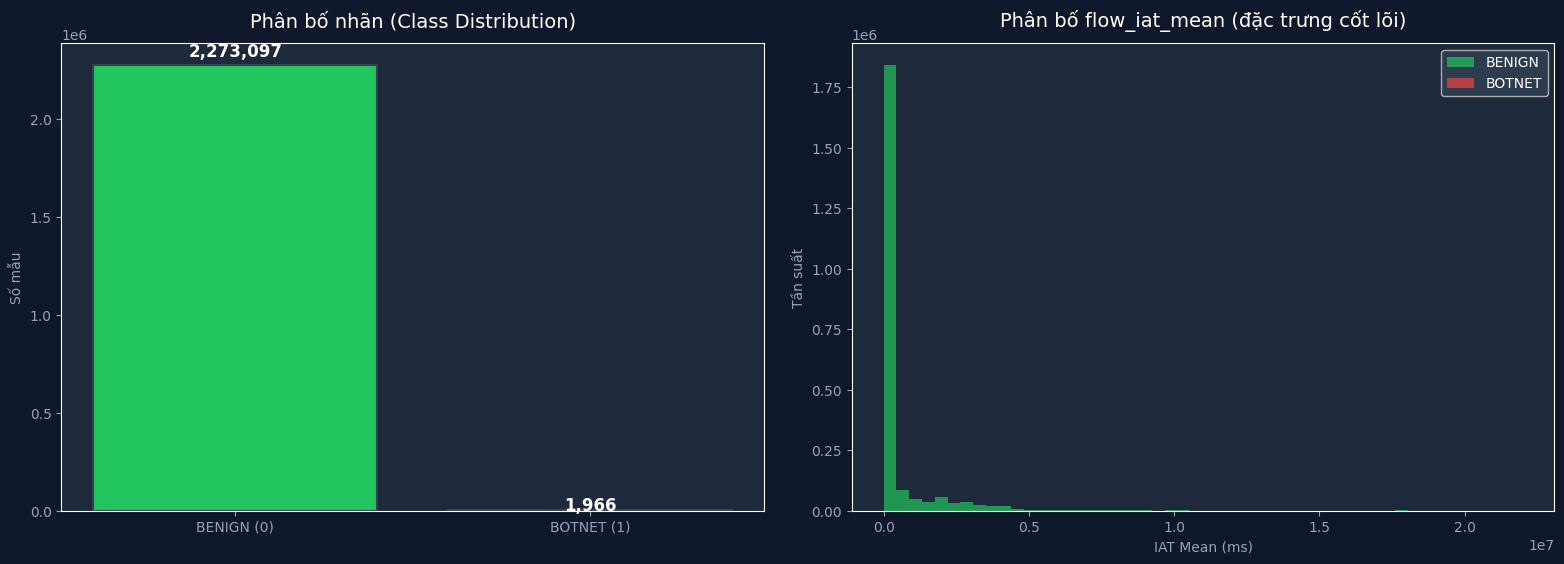


💾 Đã lưu: E:\u_a_u_o\eda_distribution.png
📋 [Báo cáo] Chèn hình này vào Mục 3.2.6.1


In [12]:
# ============================================================
# 2.2 — EDA: Phân bố đặc trưng theo class
# ============================================================
if not df_processed.empty and len(df_processed) > 100:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor('#0f172a')

    # Biểu đồ 1: Phân bố label
    ax = axes[0]; ax.set_facecolor('#1e293b')
    lc = df_processed['label'].value_counts()
    bars = ax.bar(['BENIGN (0)','BOTNET (1)'], [lc.get(0,0), lc.get(1,0)],
                  color=[SUCCESS, DANGER], edgecolor='#334155', linewidth=1.5)
    ax.set_title('Phân bố nhãn (Class Distribution)', color='white', fontsize=14, pad=12)
    ax.set_ylabel('Số mẫu', color='#94a3b8'); ax.tick_params(colors='#94a3b8')
    for bar, count in zip(bars, [lc.get(0,0), lc.get(1,0)]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                f'{count:,}', ha='center', color='white', fontsize=12, fontweight='bold')

    # Biểu đồ 2: Phân bố IAT Mean theo class
    ax = axes[1]; ax.set_facecolor('#1e293b')
    for label, color, name in [(0, SUCCESS, 'BENIGN'), (1, DANGER, 'BOTNET')]:
        data = df_processed[df_processed['label'] == label]['flow_iat_mean']
        data = data[data < data.quantile(0.99)]
        ax.hist(data, bins=50, alpha=0.7, color=color, label=name, edgecolor='none')
    ax.set_title('Phân bố flow_iat_mean (đặc trưng cốt lõi)', color='white', fontsize=14, pad=12)
    ax.set_xlabel('IAT Mean (ms)', color='#94a3b8'); ax.set_ylabel('Tần suất', color='#94a3b8')
    ax.tick_params(colors='#94a3b8'); ax.legend(facecolor='#334155', labelcolor='white')

    plt.tight_layout(pad=2.0)
    save_path = PROJECT_ROOT / 'eda_distribution.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0f172a')
    plt.show()
    print(f'\n💾 Đã lưu: {save_path}')
    print('📋 [Báo cáo] Chèn hình này vào Mục 3.2.6.1')

In [13]:
# ============================================================
# 2.3 — Tách train/test và chuẩn hóa StandardScaler
# ============================================================
if df_processed.empty:
    raise ValueError('DataFrame rỗng — không thể tiếp tục. Hãy cung cấp dữ liệu.')

X = df_processed[FLOW_FEATURES].values
y = df_processed['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

n_train_botnet = int(y_train.sum()); n_train_benign = len(y_train) - n_train_botnet
n_test_botnet  = int(y_test.sum());  n_test_benign  = len(y_test)  - n_test_botnet
SCALE_POS_WEIGHT = n_train_benign / n_train_botnet

print('📊 Tập huấn luyện (80%):')
print(f'   Tổng  : {len(X_train):,} | BENIGN: {n_train_benign:,} | BOTNET: {n_train_botnet:,}')
print(f'   scale_pos_weight = {SCALE_POS_WEIGHT:.4f}')
print(f'\n📊 Tập kiểm thử (20%):')
print(f'   Tổng  : {len(X_test):,}  | BENIGN: {n_test_benign:,} | BOTNET: {n_test_botnet:,}')

📊 Tập huấn luyện (80%):
   Tổng  : 1,820,050 | BENIGN: 1,818,477 | BOTNET: 1,573
   scale_pos_weight = 1156.0566

📊 Tập kiểm thử (20%):
   Tổng  : 455,013  | BENIGN: 454,620 | BOTNET: 393


---
## Section 3: Huấn luyện mô hình XGBoost

In [14]:
# ============================================================
# 3.1 — Khởi tạo và huấn luyện XGBClassifier
# ============================================================
print('🚀 Bắt đầu huấn luyện XGBoost...')
print(f'   n_estimators=200, max_depth=6, learning_rate=0.1')
print(f'   scale_pos_weight = {SCALE_POS_WEIGHT:.4f}')

eval_set = [(X_train_scaled, y_train), (X_test_scaled, y_test)]

xgb_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=SCALE_POS_WEIGHT,
    eval_metric='auc', random_state=42,
    verbosity=0, n_jobs=-1,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.01, reg_lambda=1.0,
    early_stopping_rounds=20,   # XGBoost 3.x: đặt ở constructor
)

t_start = time.time()
xgb_model.fit(X_train_scaled, y_train, eval_set=eval_set, verbose=False)
xgb_train_time = time.time() - t_start

print(f'\n✅ Huấn luyện hoàn tất!')
print(f'   ⏱️  Thời gian : {xgb_train_time:.2f} giây  ({OS_NAME})')
print(f'   📊 Ghi vào Bảng 3.X (Mục 3.2.6.1): Thời gian = {xgb_train_time:.2f}s')

🚀 Bắt đầu huấn luyện XGBoost...
   n_estimators=200, max_depth=6, learning_rate=0.1
   scale_pos_weight = 1156.0566

✅ Huấn luyện hoàn tất!
   ⏱️  Thời gian : 28.97 giây  (Windows)
   📊 Ghi vào Bảng 3.X (Mục 3.2.6.1): Thời gian = 28.97s


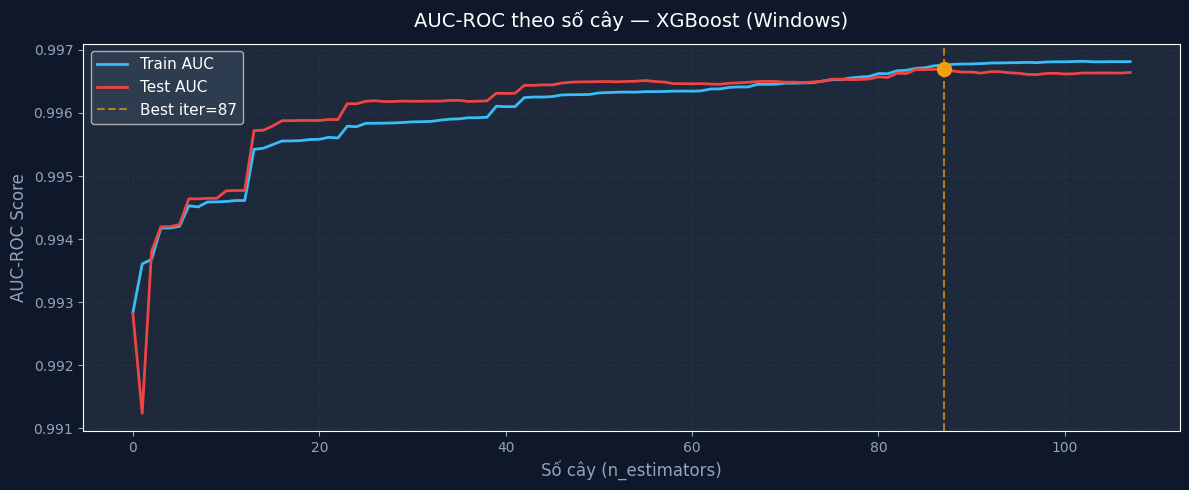


📋 [Báo cáo] Chèn hình vào Mục 3.2.6.1
   Best iteration: 87 (Test AUC-ROC = 0.9967)


In [15]:
# ============================================================
# 3.2 — Vẽ đường cong AUC-ROC theo số cây
# ============================================================
results = xgb_model.evals_result()

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0f172a'); ax.set_facecolor('#1e293b')

epochs_range = range(len(results['validation_0']['auc']))
ax.plot(epochs_range, results['validation_0']['auc'], color=ACCENT, linewidth=2, label='Train AUC')
ax.plot(epochs_range, results['validation_1']['auc'], color=DANGER, linewidth=2, label='Test AUC')

best_iter = int(np.argmax(results['validation_1']['auc']))
best_val  = results['validation_1']['auc'][best_iter]
ax.axvline(x=best_iter, color=WARNING, linestyle='--', alpha=0.7, label=f'Best iter={best_iter}')
ax.scatter([best_iter], [best_val], color=WARNING, s=100, zorder=5)

ax.set_xlabel('Số cây (n_estimators)', color='#94a3b8', fontsize=12)
ax.set_ylabel('AUC-ROC Score', color='#94a3b8', fontsize=12)
ax.set_title(f'AUC-ROC theo số cây — XGBoost ({OS_NAME})', color='white', fontsize=14, pad=12)
ax.tick_params(colors='#94a3b8'); ax.legend(facecolor='#334155', labelcolor='white', fontsize=11)
ax.grid(True, alpha=0.2, linestyle='--', color='#475569')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'xgb_auc_curve.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()

print(f'\n📋 [Báo cáo] Chèn hình vào Mục 3.2.6.1')
print(f'   Best iteration: {best_iter} (Test AUC-ROC = {best_val:.4f})')

In [16]:
# ============================================================
# 3.3 — Đánh giá toàn diện XGBoost
# ============================================================
y_pred       = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
auc       = roc_auc_score(y_test, y_pred_proba)
mcc       = matthews_corrcoef(y_test, y_pred)
cm        = confusion_matrix(y_test, y_pred)

print('=' * 55)
print('  KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH XGBOOST (tập test 20%)')
print('=' * 55)
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  AUC-ROC   : {auc:.4f}')
print(f'  MCC       : {mcc:.4f}')
print(f'\n  Confusion Matrix:')
print(f'             BENIGN  BOTNET')
print(f'  BENIGN   {cm[0,0]:>7,} {cm[0,1]:>7,}')
print(f'  BOTNET   {cm[1,0]:>7,} {cm[1,1]:>7,}')
print()
print(classification_report(y_test, y_pred, target_names=['BENIGN', 'BOTNET']))
print('📋 [Báo cáo Mục 3.2.6.1] — Sao chép kết quả vào Bảng 3.X')

xgb_results = {'precision': precision, 'recall': recall, 'f1': f1, 'auc': auc, 'mcc': mcc}

  KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH XGBOOST (tập test 20%)
  Precision : 0.0326
  Recall    : 0.9949
  F1-Score  : 0.0631
  AUC-ROC   : 0.9967
  MCC       : 0.1777

  Confusion Matrix:
             BENIGN  BOTNET
  BENIGN   443,014  11,606
  BOTNET         2     391

              precision    recall  f1-score   support

      BENIGN       1.00      0.97      0.99    454620
      BOTNET       0.03      0.99      0.06       393

    accuracy                           0.97    455013
   macro avg       0.52      0.98      0.53    455013
weighted avg       1.00      0.97      0.99    455013

📋 [Báo cáo Mục 3.2.6.1] — Sao chép kết quả vào Bảng 3.X


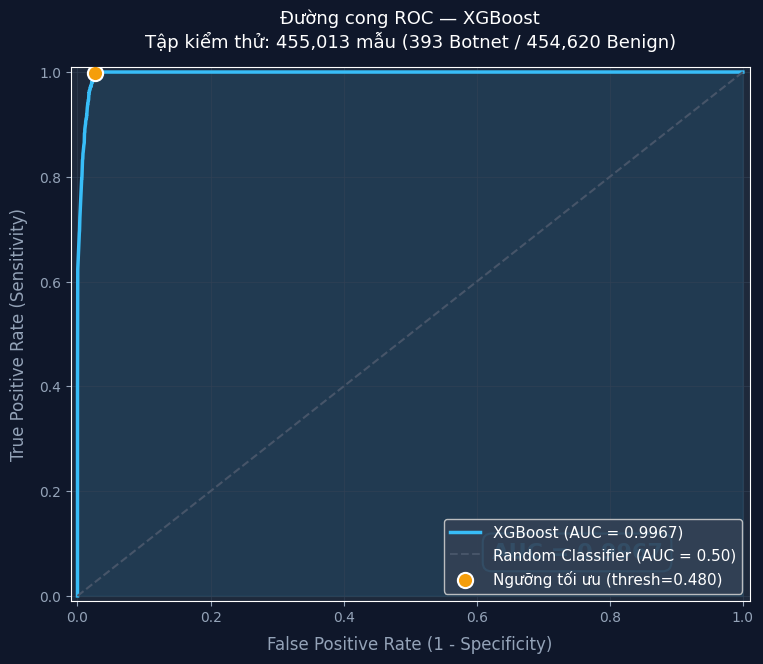


💾 Đã lưu: E:\u_a_u_o\xgboost_roc_curve.png
📋 [Báo cáo] Chèn hình này vào Mục 3.2.6 — Hình 3.x: Đường cong ROC và giá trị AUC


In [17]:
# ============================================================
# 3.3b — Đường cong ROC (Hình 3.x cho báo cáo)
# ============================================================
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#1e293b')

# --- Đường ROC chính ---
ax.plot(fpr, tpr, color=ACCENT, linewidth=2.5,
        label=f'XGBoost (AUC = {auc:.4f})')

# --- Đường tham chiếu ngẫu nhiên ---
ax.plot([0, 1], [0, 1], color='#475569', linewidth=1.5,
        linestyle='--', label='Random Classifier (AUC = 0.50)')

# --- Tô màu vùng dưới đường ROC ---
ax.fill_between(fpr, tpr, alpha=0.12, color=ACCENT)

# --- Đánh dấu điểm ngưỡng tối ưu (Youden J) ---
j_scores = tpr - fpr
best_idx = j_scores.argmax()
ax.scatter(fpr[best_idx], tpr[best_idx], s=120, zorder=5,
           color=WARNING, edgecolors='white', linewidths=1.5,
           label=f'Ngưỡng tối ưu (thresh={thresholds[best_idx]:.3f})')

# --- Nhãn trục và tiêu đề ---
ax.set_xlabel('False Positive Rate (1 - Specificity)',
              color='#94a3b8', fontsize=12, labelpad=8)
ax.set_ylabel('True Positive Rate (Sensitivity)',
              color='#94a3b8', fontsize=12, labelpad=8)
ax.set_title(
    f'Đường cong ROC — XGBoost\n'
    f'Tập kiểm thử: {len(y_test):,} mẫu '
    f'({int(y_test.sum()):,} Botnet / {int((y_test==0).sum()):,} Benign)',
    color='white', fontsize=13, pad=14
)

# --- Chú thích và lưới ---
ax.legend(facecolor='#334155', labelcolor='white', fontsize=11,
          framealpha=0.9, loc='lower right')
ax.tick_params(colors='#94a3b8')
ax.set_xlim(-0.01, 1.01); ax.set_ylim(-0.01, 1.01)
ax.grid(True, color='#334155', linewidth=0.6, alpha=0.7)

# --- Annotation AUC ---
ax.text(0.62, 0.08,
        f'AUC = {auc:.4f}',
        transform=ax.transAxes,
        fontsize=16, fontweight='bold', color=ACCENT,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#1e293b',
                  edgecolor=ACCENT, linewidth=1.5))

plt.tight_layout(pad=2.0)
save_path = PROJECT_ROOT / 'xgboost_roc_curve.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print(f'\n💾 Đã lưu: {save_path}')
print('📋 [Báo cáo] Chèn hình này vào Mục 3.2.6 — Hình 3.x: Đường cong ROC và giá trị AUC')


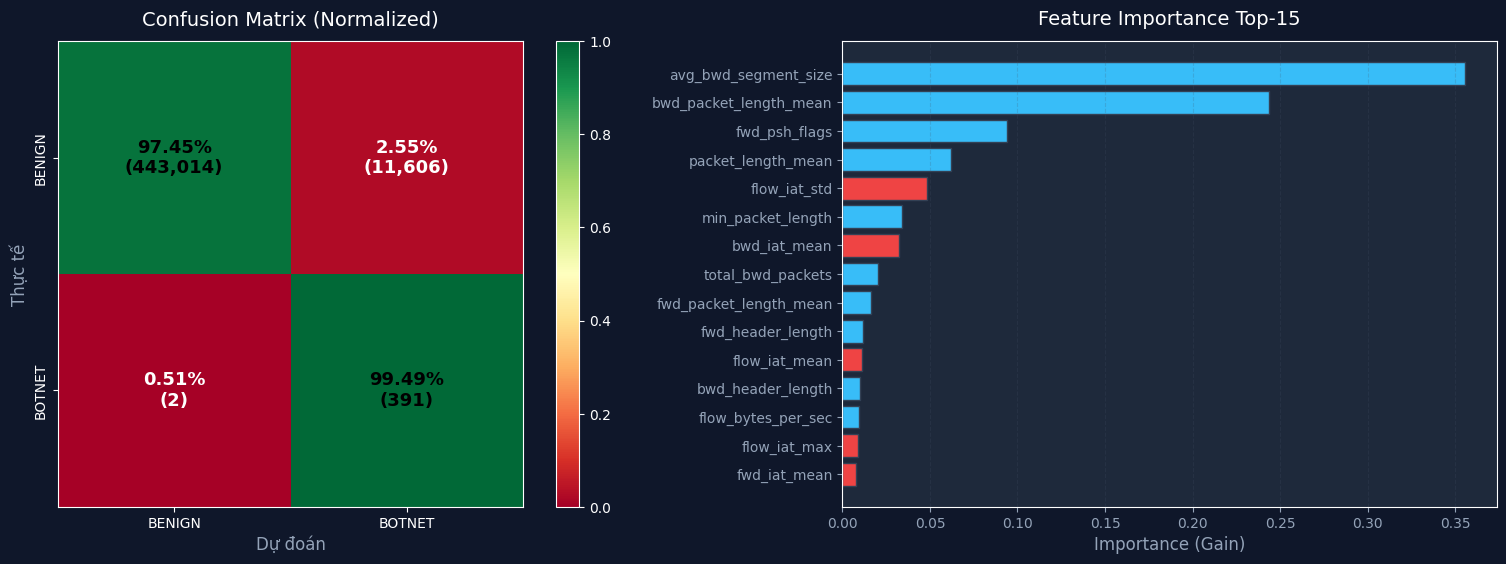

📋 [Báo cáo] Chèn hình vào Mục 3.2.6.1

📊 Bảng Feature Importance Top-10:
Rank   Đặc trưng                             Importance
-------------------------------------------------------
1      avg_bwd_segment_size                    0.355880
2      bwd_packet_length_mean                  0.243619
3      fwd_psh_flags                           0.093882
4      packet_length_mean                      0.062137
5      flow_iat_std                            0.048317
6      min_packet_length                       0.034030
7      bwd_iat_mean                            0.032125
8      total_bwd_packets                       0.020151
9      fwd_packet_length_mean                  0.016576
10     fwd_header_length                       0.011774


In [18]:
# ============================================================
# 3.4 — Confusion Matrix + Feature Importance
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f172a')

# Confusion Matrix
ax = axes[0]; ax.set_facecolor('#1e293b')
cm_norm = cm.astype(float)
for i in range(2): cm_norm[i] /= cm_norm[i].sum()
im = ax.imshow(cm_norm, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks([0,1]); ax.set_xticklabels(['BENIGN','BOTNET'], color='white')
ax.set_yticks([0,1]); ax.set_yticklabels(['BENIGN','BOTNET'], color='white', rotation=90, va='center')
ax.set_xlabel('Dự đoán', color='#94a3b8', fontsize=12)
ax.set_ylabel('Thực tế', color='#94a3b8', fontsize=12)
ax.set_title('Confusion Matrix (Normalized)', color='white', fontsize=14, pad=12)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm_norm[i,j]:.2%}\n({cm[i,j]:,})', ha='center', va='center',
                color='black' if cm_norm[i,j]>0.5 else 'white', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax)

# Feature Importance
ax = axes[1]; ax.set_facecolor('#1e293b')
importances = xgb_model.feature_importances_
feat_imp = pd.DataFrame({'feature': FLOW_FEATURES, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=True).tail(15)
colors = [DANGER if any(k in f for k in ['idle','iat','active']) else ACCENT for f in feat_imp['feature']]
ax.barh(feat_imp['feature'], feat_imp['importance'], color=colors, edgecolor='#334155')
ax.set_xlabel('Importance (Gain)', color='#94a3b8', fontsize=12)
ax.set_title('Feature Importance Top-15', color='white', fontsize=14, pad=12)
ax.tick_params(colors='#94a3b8'); ax.grid(True, alpha=0.2, linestyle='--', color='#475569', axis='x')

plt.tight_layout(pad=2.0)
plt.savefig(PROJECT_ROOT / 'xgb_evaluation.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()

print('📋 [Báo cáo] Chèn hình vào Mục 3.2.6.1')
print('\n📊 Bảng Feature Importance Top-10:')
top10 = feat_imp.tail(10)[::-1]
print(f'{"Rank":<6} {"Đặc trưng":<35} {"Importance":>12}')
print('-' * 55)
for i, (_, row) in enumerate(top10.iterrows(), 1):
    print(f'{i:<6} {row["feature"]:<35} {row["importance"]:>12.6f}')

---
## Section 4: Lưu model XGBoost

In [19]:
# ============================================================
# 4.1 — Lưu model và kiểm tra cross-platform
# ============================================================
from datetime import datetime

MODEL_PATH  = MODELS_DIR / 'xgboost_flow_model.joblib'
SCALER_PATH = MODELS_DIR / 'flow_scaler.joblib'

joblib.dump(xgb_model, MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

def md5(filepath: Path) -> str:
    h = hashlib.md5()
    with open(filepath, 'rb') as f: h.update(f.read())
    return h.hexdigest()

model_size  = MODEL_PATH.stat().st_size / 1024
scaler_size = SCALER_PATH.stat().st_size / 1024
now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

print('✅ Model XGBoost đã được lưu:')
print(f'   📁 {MODEL_PATH}')
print(f'      Kích thước : {model_size:.1f} KB')
print(f'      MD5        : {md5(MODEL_PATH)}')
print(f'      Ngày tạo   : {now}  [OS: {OS_NAME}]')
print()
print(f'   📁 {SCALER_PATH}')
print(f'      Kích thước : {scaler_size:.1f} KB')
print(f'      MD5        : {md5(SCALER_PATH)}')
print()
print('📋 [Báo cáo Bảng 3.X Mục 3.2.6.3] — Sao chép thông tin trên')

# Kiểm tra inference sau tải lại (cross-platform)
loaded_model  = joblib.load(MODEL_PATH)
loaded_scaler = joblib.load(SCALER_PATH)

sample_cnc = np.zeros((1, len(FLOW_FEATURES)))
sample_cnc[0, FLOW_FEATURES.index('flow_iat_mean')] = 60000
sample_cnc[0, FLOW_FEATURES.index('flow_iat_std')]  = 50
sample_cnc[0, FLOW_FEATURES.index('active_mean')]   = 10
sample_cnc[0, FLOW_FEATURES.index('idle_mean')]     = 60000

t0 = time.perf_counter()
for _ in range(100):
    s = loaded_scaler.transform(np.zeros((1, len(FLOW_FEATURES))))
    loaded_model.predict_proba(s)
t_inf = (time.perf_counter() - t0) / 100 * 1000

prob_cnc = loaded_model.predict_proba(loaded_scaler.transform(sample_cnc))[0]
print(f'🔍 Inference test: Sample C&C → P(C&C)={prob_cnc[1]:.4f}  ✓')
print(f'   Latency ~{t_inf:.2f} ms/flow  ({OS_NAME})')

xgb_metadata = {
    'model_size_kb': model_size, 'model_md5': md5(MODEL_PATH),
    'scaler_size_kb': scaler_size, 'scaler_md5': md5(SCALER_PATH),
    'created_at': now, 'os': OS_NAME,
    'train_time_sec': xgb_train_time, 'inference_ms': t_inf,
    **xgb_results
}

✅ Model XGBoost đã được lưu:
   📁 E:\u_a_u_o\cnc-detector\models\xgboost_flow_model.joblib
      Kích thước : 257.0 KB
      MD5        : 07643da5e7ecc1f3c3d6efd64f4307cb
      Ngày tạo   : 2026-05-28 01:05:57  [OS: Windows]

   📁 E:\u_a_u_o\cnc-detector\models\flow_scaler.joblib
      Kích thước : 1.4 KB
      MD5        : 97ea0dbaf48d476335aeb8887729c5c5

📋 [Báo cáo Bảng 3.X Mục 3.2.6.3] — Sao chép thông tin trên
🔍 Inference test: Sample C&C → P(C&C)=0.0009  ✓
   Latency ~0.60 ms/flow  (Windows)


---
## Section 5: Tải và tiền xử lý dữ liệu DGA (Bi-LSTM)

In [20]:
# ============================================================
# 5.1 — Tải dữ liệu domain (Benign + DGA)
# ============================================================
def load_domain_list(filepath: Path) -> list:
    if not filepath.exists(): return []
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        return [l.strip().lower() for l in f if l.strip() and not l.startswith('#')]

benign_domains = load_domain_list(DGA_DIR / 'benign_domains.txt')
dga_domains    = load_domain_list(DGA_DIR / 'dga_domains.txt')

print(f'📂 benign_domains.txt: {len(benign_domains):,} domains')
print(f'📂 dga_domains.txt   : {len(dga_domains):,} domains')

USE_SYNTHETIC_DGA = not (benign_domains and dga_domains)
if USE_SYNTHETIC_DGA:
    print('\n[INFO] Dùng synthetic domain data')
    benign_seeds = [
        'google','youtube','facebook','amazon','microsoft','apple','netflix',
        'github','stackoverflow','cloudflare','twitter','linkedin','reddit',
        'office','mozilla','dropbox','instagram','mail','smtp','cdn','docs',
        'help','news','shop','store','media','images','assets','api','update',
        'windows','portal','support','download','static','login','secure',
    ]
    benign_domains = (benign_seeds * 200)[:5000]
    np.random.seed(42)
    dga_domains = [
        ''.join(np.random.choice(list('abcdefghijklmnopqrstuvwxyz0123456789'),
                                 np.random.randint(10, 28)))
        for _ in range(2000)
    ]

print(f'\n✅ Benign: {len(benign_domains):,} | DGA: {len(dga_domains):,} | Tổng: {len(benign_domains)+len(dga_domains):,}')

📂 benign_domains.txt: 0 domains
📂 dga_domains.txt   : 0 domains

[INFO] Dùng synthetic domain data

✅ Benign: 5,000 | DGA: 2,000 | Tổng: 7,000


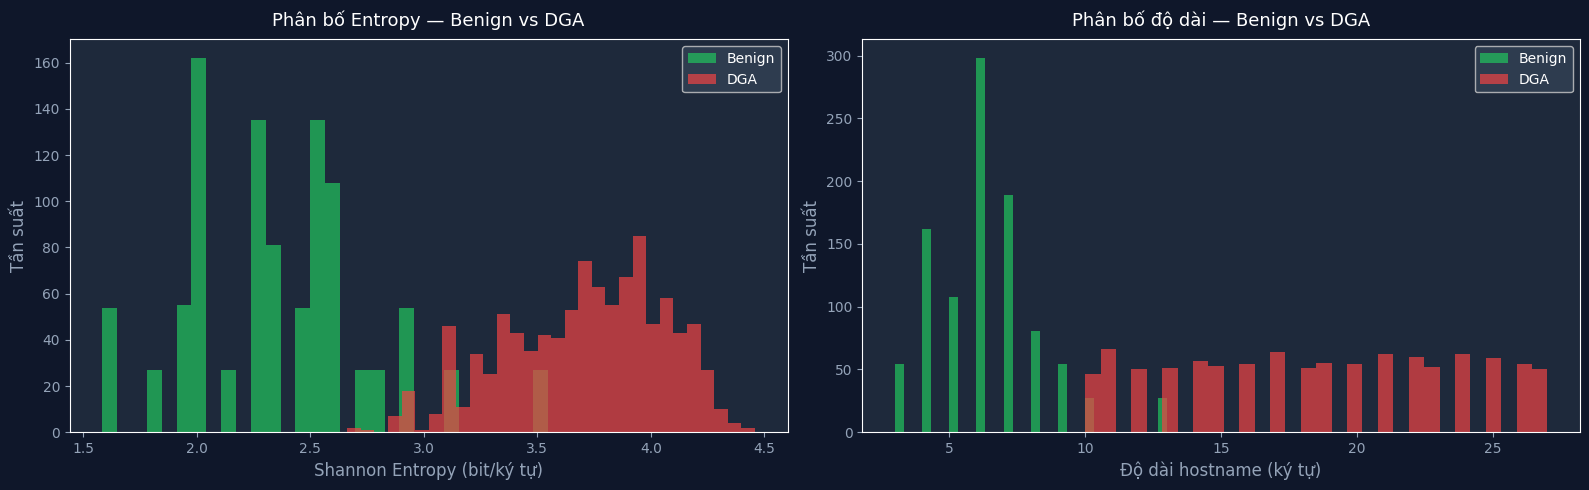

Entropy — Benign: μ=2.357, σ=0.410 | DGA: μ=3.707, σ=0.350


In [21]:
# ============================================================
# 5.2 — EDA: Entropy & độ dài domain
# ============================================================
def calc_entropy(s: str) -> float:
    if not s: return 0.0
    prob = [s.count(c)/len(s) for c in set(s)]
    return -sum(p * math.log2(p) for p in prob if p > 0)

def get_hostname(domain: str) -> str:
    return domain.lower().split('.')[0] if '.' in domain else domain.lower()

s_benign = benign_domains[:1000]; s_dga = dga_domains[:1000]
be = [calc_entropy(get_hostname(d)) for d in s_benign]
de = [calc_entropy(get_hostname(d)) for d in s_dga]
bl = [len(get_hostname(d)) for d in s_benign]
dl = [len(get_hostname(d)) for d in s_dga]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f172a')
for ax, data_b, data_d, xlabel, title in [
    (axes[0], be, de, 'Shannon Entropy (bit/ký tự)', 'Phân bố Entropy — Benign vs DGA'),
    (axes[1], bl, dl, 'Độ dài hostname (ký tự)', 'Phân bố độ dài — Benign vs DGA'),
]:
    ax.set_facecolor('#1e293b')
    ax.hist(data_b, bins=30, alpha=0.7, color=SUCCESS, label='Benign', edgecolor='none')
    ax.hist(data_d, bins=30, alpha=0.7, color=DANGER,  label='DGA',    edgecolor='none')
    ax.set_xlabel(xlabel, color='#94a3b8', fontsize=12)
    ax.set_ylabel('Tần suất', color='#94a3b8', fontsize=12)
    ax.set_title(title, color='white', fontsize=13, pad=10)
    ax.tick_params(colors='#94a3b8'); ax.legend(facecolor='#334155', labelcolor='white')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'dga_eda.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print(f'Entropy — Benign: μ={np.mean(be):.3f}, σ={np.std(be):.3f} | DGA: μ={np.mean(de):.3f}, σ={np.std(de):.3f}')

In [22]:
# ============================================================
# 5.3 — Tokenization và chuẩn bị tensor input
# ============================================================
char_to_idx = {ch: i+1 for i, ch in enumerate(VALID_CHARS)}
char_to_idx['<UNK>'] = len(char_to_idx) + 1
vocab_size = len(char_to_idx) + 2

def tokenize(domain: str) -> np.ndarray:
    hostname = domain.lower().split('.')[0][:MAX_LEN]
    tokens = [char_to_idx.get(c, char_to_idx['<UNK>']) for c in hostname]
    padded = tokens + [0] * (MAX_LEN - len(tokens))
    return np.array(padded[:MAX_LEN], dtype=np.int32)

print('⚙️ Tokenizing domains...')
all_domains = benign_domains + dga_domains
all_labels  = [0] * len(benign_domains) + [1] * len(dga_domains)

X_dga = np.array([tokenize(d) for d in tqdm(all_domains, desc='Tokenizing')])
y_dga = np.array(all_labels)

idx = np.random.RandomState(42).permutation(len(X_dga))
X_dga, y_dga = X_dga[idx], y_dga[idx]

X_dga_train, X_dga_test, y_dga_train, y_dga_test = train_test_split(
    X_dga, y_dga, test_size=0.2, random_state=42, stratify=y_dga
)

print(f'\n✅ Vocab size: {vocab_size} | MAX_LEN: {MAX_LEN} | Shape: {X_dga.shape}')
print(f'   Train: {len(X_dga_train):,} | Test: {len(X_dga_test):,}')

CHAR_MAP_PATH = MODELS_DIR / 'char_map.npy'
np.save(CHAR_MAP_PATH, np.array(VALID_CHARS))
print(f'\n💾 char_map.npy → {CHAR_MAP_PATH}')

⚙️ Tokenizing domains...


Tokenizing: 100%|██████████| 7000/7000 [00:00<00:00, 268131.47it/s]


✅ Vocab size: 41 | MAX_LEN: 64 | Shape: (7000, 64)
   Train: 5,600 | Test: 1,400

💾 char_map.npy → E:\u_a_u_o\cnc-detector\models\char_map.npy


---
## Section 6: Xây dựng và huấn luyện mô hình Bi-LSTM

In [23]:
# ============================================================
# 6.1 — Xây dựng kiến trúc Bi-LSTM (cross-platform)
# ============================================================
if not TF_AVAILABLE:
    print('[SKIP] TensorFlow không khả dụng — bỏ qua Section 6–8')
    print('[HINT] Cài đặt theo OS:')
    if IS_WINDOWS:
        print('  Windows: pip install tensorflow')
    elif IS_LINUX:
        print('  Linux CPU: pip install tensorflow')
        print('  Linux GPU: pip install tensorflow[and-cuda]')
else:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, SpatialDropout1D, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
    import tensorflow as tf
    tf.random.set_seed(42); np.random.seed(42)

    bilstm_model = Sequential(name='BiLSTM_DGA_Detector', layers=[
        Embedding(vocab_size, 64, input_length=MAX_LEN, mask_zero=True, name='embedding'),
        SpatialDropout1D(0.3, name='spatial_dropout'),
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2), name='bilstm_1'),
        Bidirectional(LSTM(64, dropout=0.2), name='bilstm_2'),
        Dense(64, activation='relu', name='dense_1'),
        Dropout(0.4, name='dropout'),
        Dense(1, activation='sigmoid', name='output'),
    ])

    from tensorflow.keras.optimizers import Adam
    bilstm_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    bilstm_model.build(input_shape=(None, MAX_LEN))  # Keras 3.x: build trước count_params
    bilstm_model.summary()
    print(f'\n📊 Tổng tham số: {bilstm_model.count_params():,}')
    print(f'📋 [Báo cáo Bảng 3.5] — Số tham số thực tế = {bilstm_model.count_params():,}')
    print(f'\n💡 GPU: {GPU_INFO}  ({OS_NAME})')

Model: "BiLSTM_DGA_Detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 64, 64)         │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 64, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 64, 256)        │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 372,929 (1.42 MB)

 Trainable params: 372,929 (1.42 MB)

 Non-trainable params: 0 (0.00 B)


📊 Tổng tham số: 372,929
📋 [Báo cáo Bảng 3.5] — Số tham số thực tế = 372,929

💡 GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU, 4096 MiB  (Windows)


In [24]:
# ============================================================
# 6.2 — Huấn luyện Bi-LSTM với callbacks
# ============================================================
if TF_AVAILABLE:
    BILSTM_CKPT = MODELS_DIR / 'bilstm_checkpoint.keras'

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
        ModelCheckpoint(filepath=str(BILSTM_CKPT), monitor='val_loss', save_best_only=True, verbose=0),
    ]

    print('🚀 Bắt đầu huấn luyện Bi-LSTM...')
    print(f'   batch_size=64, epochs=10 (max), EarlyStopping patience=3')
    print(f'   [{OS_NAME}] {GPU_INFO}')

    t_start_lstm = time.time()
    history = bilstm_model.fit(
        X_dga_train, y_dga_train,
        batch_size=64, epochs=10, validation_split=0.2,
        callbacks=callbacks, verbose=1
    )
    lstm_train_time = time.time() - t_start_lstm

    print(f'\n✅ Huấn luyện hoàn tất!  [{OS_NAME}]')
    print(f'   ⏱️  Tổng thời gian  : {lstm_train_time:.2f} giây')
    print(f'   ⏱️  Thời gian/epoch : {lstm_train_time/len(history.epoch):.2f} giây')
    print(f'   📊 Số epoch thực tế: {len(history.epoch)}')
    print(f'📋 [Báo cáo Bảng 3.X Mục 3.2.6.2] — Ghi nhớ các giá trị trên')

🚀 Bắt đầu huấn luyện Bi-LSTM...
   batch_size=64, epochs=10 (max), EarlyStopping patience=3
   [Windows] NVIDIA GeForce RTX 3050 Ti Laptop GPU, 4096 MiB
Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 147ms/step - accuracy: 0.9344 - loss: 0.1793 - val_accuracy: 0.9991 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 148ms/step - accuracy: 0.9984 - loss: 0.0060 - val_accuracy: 1.0000 - val_loss: 5.7238e-04 - learning_rate: 0.0010
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 161ms/step - accuracy: 0.9987 - loss: 0.0053 - val_accuracy: 1.0000 - val_loss: 3.3474e-04 - learning_rate: 0.0010
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.9991 - loss: 0.0045 - val_accuracy: 1.0000 - val_loss: 4.9762e-04 - learning_rate: 0.0010
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 1.0000 - loss: 9.5445e-04 - val_accuracy: 1.0000 - val_loss: 5.3708e-05 - learning_rate: 0.0010
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accurac

---
## Section 7: Đánh giá mô hình Bi-LSTM

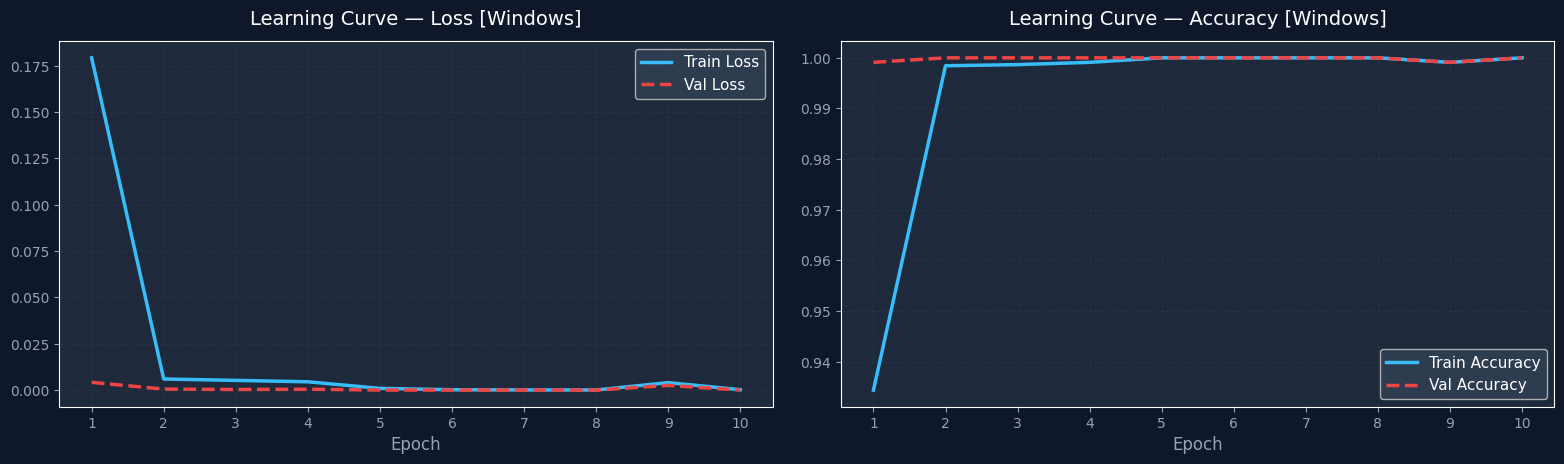

📋 [Báo cáo] Chèn hình vào Mục 3.2.6.2


In [25]:
# ============================================================
# 7.1 — Learning Curve
# ============================================================
if TF_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.patch.set_facecolor('#0f172a')
    ep = range(1, len(history.epoch) + 1)

    for ax, metric, title in [
        (axes[0], 'loss',     'Learning Curve — Loss'),
        (axes[1], 'accuracy', 'Learning Curve — Accuracy'),
    ]:
        ax.set_facecolor('#1e293b')
        ax.plot(ep, history.history[metric],       color=ACCENT, linewidth=2.5, label=f'Train {metric.capitalize()}')
        ax.plot(ep, history.history[f'val_{metric}'], color=DANGER, linewidth=2.5, label=f'Val {metric.capitalize()}', linestyle='--')
        ax.set_xlabel('Epoch', color='#94a3b8', fontsize=12)
        ax.set_title(f'{title} [{OS_NAME}]', color='white', fontsize=14, pad=12)
        ax.tick_params(colors='#94a3b8'); ax.legend(facecolor='#334155', labelcolor='white', fontsize=11)
        ax.grid(True, alpha=0.2, linestyle='--', color='#475569'); ax.set_xticks(ep)

    plt.tight_layout(pad=2.0)
    plt.savefig(PROJECT_ROOT / 'bilstm_learning_curve.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
    plt.show()
    print('📋 [Báo cáo] Chèn hình vào Mục 3.2.6.2')

  KẾT QUẢ ĐÁNH GIÁ Bi-LSTM (tập test 20%)
  Precision : 1.0000 | Recall: 1.0000 | F1: 1.0000
  AUC-ROC   : 1.0000 | MCC   : 1.0000
  Inference : 1.361 ms/domain  [Windows]

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00      1000
         DGA       1.00      1.00      1.00       400

    accuracy                           1.00      1400
   macro avg       1.00      1.00      1.00      1400
weighted avg       1.00      1.00      1.00      1400



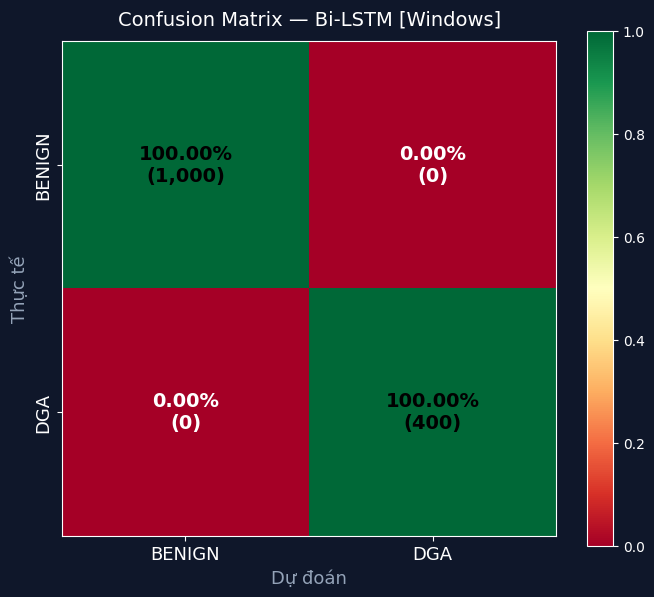

📋 [Báo cáo] Chèn hình vào Mục 3.2.6.2


In [26]:
# ============================================================
# 7.2 — Đánh giá và Confusion Matrix
# ============================================================
if TF_AVAILABLE:
    t0 = time.perf_counter()
    y_dga_pred_proba = bilstm_model.predict(X_dga_test, batch_size=128, verbose=0)
    t_inf_lstm = (time.perf_counter() - t0) / len(X_dga_test) * 1000

    y_dga_pred = (y_dga_pred_proba > 0.5).astype(int).flatten()
    prec = precision_score(y_dga_test, y_dga_pred, zero_division=0)
    rec  = recall_score(y_dga_test, y_dga_pred, zero_division=0)
    f1d  = f1_score(y_dga_test, y_dga_pred, zero_division=0)
    aucd = roc_auc_score(y_dga_test, y_dga_pred_proba.flatten())
    mccd = matthews_corrcoef(y_dga_test, y_dga_pred)
    cm_d = confusion_matrix(y_dga_test, y_dga_pred)

    print('=' * 55)
    print('  KẾT QUẢ ĐÁNH GIÁ Bi-LSTM (tập test 20%)')
    print('=' * 55)
    print(f'  Precision : {prec:.4f} | Recall: {rec:.4f} | F1: {f1d:.4f}')
    print(f'  AUC-ROC   : {aucd:.4f} | MCC   : {mccd:.4f}')
    print(f'  Inference : {t_inf_lstm:.3f} ms/domain  [{OS_NAME}]')
    print()
    print(classification_report(y_dga_test, y_dga_pred, target_names=['BENIGN','DGA']))

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(7, 6))
    fig.patch.set_facecolor('#0f172a'); ax.set_facecolor('#1e293b')
    cm_n = cm_d.astype(float)
    for i in range(2): cm_n[i] /= cm_n[i].sum()
    im = ax.imshow(cm_n, cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_xticks([0,1]); ax.set_xticklabels(['BENIGN','DGA'], color='white', fontsize=13)
    ax.set_yticks([0,1]); ax.set_yticklabels(['BENIGN','DGA'], color='white', fontsize=13, rotation=90, va='center')
    ax.set_xlabel('Dự đoán', color='#94a3b8', fontsize=13)
    ax.set_ylabel('Thực tế', color='#94a3b8', fontsize=13)
    ax.set_title(f'Confusion Matrix — Bi-LSTM [{OS_NAME}]', color='white', fontsize=14, pad=12)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm_n[i,j]:.2%}\n({cm_d[i,j]:,})', ha='center', va='center',
                    color='black' if cm_n[i,j]>0.5 else 'white', fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax); plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'bilstm_confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
    plt.show()
    print('📋 [Báo cáo] Chèn hình vào Mục 3.2.6.2')

    lstm_results = {'precision': prec, 'recall': rec, 'f1': f1d, 'auc': aucd, 'mcc': mccd, 'inference_ms': t_inf_lstm}

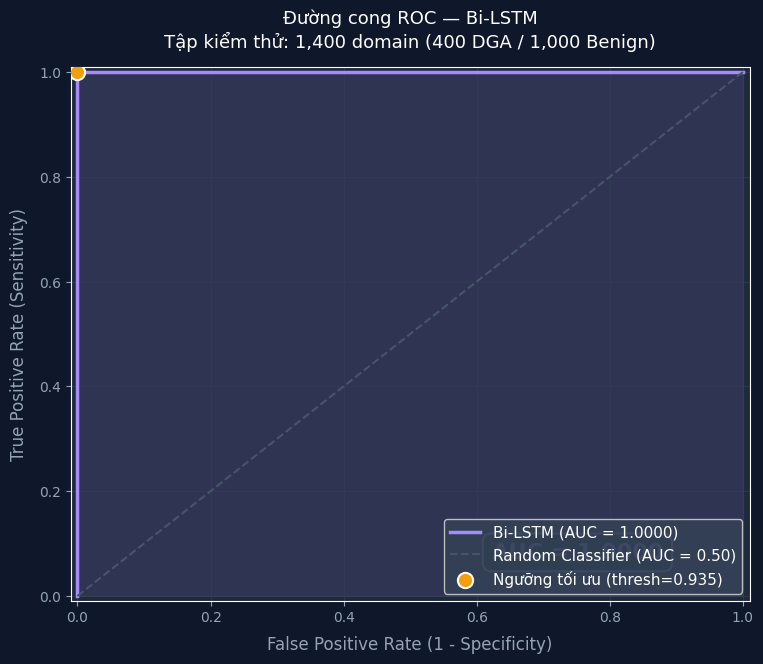


💾 Đã lưu: E:\u_a_u_o\bilstm_roc_curve.png
📋 [Báo cáo] Chèn hình này vào Mục 3.2.6 — Hình 3.x: Đường cong ROC và giá trị AUC Bi-LSTM


In [27]:
# ============================================================
# 7.2b — Đường cong ROC Bi-LSTM (Hình 3.x cho báo cáo)
# ============================================================
if TF_AVAILABLE:
    from sklearn.metrics import roc_curve, roc_auc_score

    _proba = y_dga_pred_proba.flatten()
    auc_dga = roc_auc_score(y_dga_test, _proba)
    fpr_d, tpr_d, thresh_d = roc_curve(y_dga_test, _proba)

    fig, ax = plt.subplots(figsize=(8, 7))
    fig.patch.set_facecolor('#0f172a')
    ax.set_facecolor('#1e293b')

    # --- Đường ROC chính ---
    ax.plot(fpr_d, tpr_d, color='#a78bfa', linewidth=2.5,
            label=f'Bi-LSTM (AUC = {auc_dga:.4f})')

    # --- Đường tham chiếu ngẫu nhiên ---
    ax.plot([0, 1], [0, 1], color='#475569', linewidth=1.5,
            linestyle='--', label='Random Classifier (AUC = 0.50)')

    # --- Tô màu vùng dưới đường ROC ---
    ax.fill_between(fpr_d, tpr_d, alpha=0.12, color='#a78bfa')

    # --- Đánh dấu điểm ngưỡng tối ưu (Youden J) ---
    j_d = tpr_d - fpr_d
    best_d = j_d.argmax()
    ax.scatter(fpr_d[best_d], tpr_d[best_d], s=120, zorder=5,
               color=WARNING, edgecolors='white', linewidths=1.5,
               label=f'Ngưỡng tối ưu (thresh={thresh_d[best_d]:.3f})')

    # --- Nhãn trục và tiêu đề ---
    ax.set_xlabel('False Positive Rate (1 - Specificity)',
                  color='#94a3b8', fontsize=12, labelpad=8)
    ax.set_ylabel('True Positive Rate (Sensitivity)',
                  color='#94a3b8', fontsize=12, labelpad=8)
    ax.set_title(
        f'Đường cong ROC — Bi-LSTM\n'
        f'Tập kiểm thử: {len(y_dga_test):,} domain '
        f'({int(y_dga_test.sum()):,} DGA / {int((y_dga_test==0).sum()):,} Benign)',
        color='white', fontsize=13, pad=14
    )

    # --- Chú thích và lưới ---
    ax.legend(facecolor='#334155', labelcolor='white', fontsize=11,
              framealpha=0.9, loc='lower right')
    ax.tick_params(colors='#94a3b8')
    ax.set_xlim(-0.01, 1.01); ax.set_ylim(-0.01, 1.01)
    ax.grid(True, color='#334155', linewidth=0.6, alpha=0.7)

    # --- Annotation AUC ---
    ax.text(0.62, 0.08,
            f'AUC = {auc_dga:.4f}',
            transform=ax.transAxes,
            fontsize=16, fontweight='bold', color='#a78bfa',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#1e293b',
                      edgecolor='#a78bfa', linewidth=1.5))

    plt.tight_layout(pad=2.0)
    save_path = PROJECT_ROOT / 'bilstm_roc_curve.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0f172a')
    plt.show()
    print(f'\n💾 Đã lưu: {save_path}')
    print('📋 [Báo cáo] Chèn hình này vào Mục 3.2.6 — Hình 3.x: Đường cong ROC và giá trị AUC Bi-LSTM')


---
## Section 8: Lưu model Bi-LSTM

In [28]:
# ============================================================
# 8.1 — Lưu và kiểm tra inference cross-platform
# ============================================================
if TF_AVAILABLE:
    BILSTM_PATH = MODELS_DIR / 'bilstm_dga_model.keras'
    bilstm_model.save(str(BILSTM_PATH))

    bilstm_size = BILSTM_PATH.stat().st_size / (1024 * 1024)
    now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

    print('✅ Model Bi-LSTM đã được lưu:')
    print(f'   📁 {BILSTM_PATH}')
    print(f'      Kích thước : {bilstm_size:.2f} MB')
    print(f'      MD5        : {md5(BILSTM_PATH)}')
    print(f'      Ngày tạo   : {now}  [OS: {OS_NAME}]')
    print(f'      Số tham số : {bilstm_model.count_params():,}')
    print()

    # Kiểm tra tải lại (format .keras tương thích cross-platform)
    loaded_lstm = tf.keras.models.load_model(str(BILSTM_PATH))
    p_benign = float(loaded_lstm.predict(tokenize('google').reshape(1,-1), verbose=0)[0][0])
    p_dga    = float(loaded_lstm.predict(tokenize('xkqmwprzyolab').reshape(1,-1), verbose=0)[0][0])

    print('🔍 Inference test sau tải lại:')
    print(f'   "google"       → P(DGA)={p_benign:.4f}  {"✓ Benign" if p_benign<0.5 else "⚠️ Nhầm"}')
    print(f'   "xkqmwprzyolab"→ P(DGA)={p_dga:.4f}  {"✓ DGA" if p_dga>=0.5 else "⚠️ Nhầm"}')
    print()
    print('📝 Lưu ý cross-platform: file .keras tương thích giữa Windows và Linux')
    print('   Có thể train trên Linux GPU rồi copy sang Windows để deploy.')
    print('📋 [Báo cáo Mục 3.2.6.3] — Sao chép thông tin model vào Bảng 3.X')

    lstm_metadata = {
        'model_size_mb': bilstm_size, 'model_md5': md5(BILSTM_PATH),
        'n_params': bilstm_model.count_params(),
        'train_time_sec': lstm_train_time, 'n_epochs': len(history.epoch),
        'os': OS_NAME, **lstm_results
    }

✅ Model Bi-LSTM đã được lưu:
   📁 E:\u_a_u_o\cnc-detector\models\bilstm_dga_model.keras
      Kích thước : 4.33 MB
      MD5        : 2e997ef1b885faa40452d1231371e656
      Ngày tạo   : 2026-05-28 01:07:47  [OS: Windows]
      Số tham số : 372,929

🔍 Inference test sau tải lại:
   "google"       → P(DGA)=0.0000  ✓ Benign
   "xkqmwprzyolab"→ P(DGA)=1.0000  ✓ DGA

📝 Lưu ý cross-platform: file .keras tương thích giữa Windows và Linux
   Có thể train trên Linux GPU rồi copy sang Windows để deploy.
📋 [Báo cáo Mục 3.2.6.3] — Sao chép thông tin model vào Bảng 3.X


---
## Section 9: Tổng kết và bảng kết quả cho báo cáo

In [29]:
# ============================================================
# 9.1 — Bảng tổng kết (sao chép vào Mục 3.2.6 báo cáo)
# ============================================================
print('=' * 70)
print('  BẢNG TỔNG KẾT — SAO CHÉP VÀO MỤC 3.2.6 BÁO CÁO')
print(f'  [Môi trường: {OS_NAME} {OS_RELEASE} | AVX: {AVX_SUPPORTED} | GPU: {GPU_INFO}]')
print('=' * 70)

print('\n--- Bảng 3.X: Thông tin môi trường (Mục 3.1.4) ---')
print(f'  OS            : {OS_NAME} {OS_RELEASE}')
print(f'  Python        : {sys.version.split()[0]}')
print(f'  AVX support   : {AVX_SUPPORTED}')
print(f'  GPU           : {GPU_INFO}')

print('\n--- Bảng 3.X: Dataset XGBoost (Mục 3.2.6.1) ---')
print(f'  Tổng samples  : {len(df_processed):,}')
print(f'  BENIGN        : {int(n_train_benign+n_test_benign):,}')
print(f'  BOTNET        : {int(n_train_botnet+n_test_botnet):,}')
print(f'  scale_pos_wt  : {SCALE_POS_WEIGHT:.4f}')

print('\n--- Bảng 3.X: Kết quả XGBoost (Mục 3.2.6.1) ---')
for k, v in xgb_results.items(): print(f'  {k:<12}: {v:.4f}')
print(f'  Train time    : {xgb_train_time:.2f} giây  [{OS_NAME}]')
print(f'  Inference     : ~{xgb_metadata.get("inference_ms",0):.2f} ms/flow')
print(f'  Model size    : {xgb_metadata.get("model_size_kb",0):.1f} KB')
print(f'  MD5 (model)   : {xgb_metadata.get("model_md5","N/A")}')

if TF_AVAILABLE:
    print('\n--- Bảng 3.X: Dataset DGA (Mục 3.2.6.2) ---')
    print(f'  Benign domains: {len(benign_domains):,}')
    print(f'  DGA domains   : {len(dga_domains):,}')

    print('\n--- Bảng 3.X: Kết quả Bi-LSTM (Mục 3.2.6.2) ---')
    for k, v in lstm_results.items(): print(f'  {k:<12}: {v:.4f}')
    print(f'  Train time    : {lstm_train_time:.2f} giây ({len(history.epoch)} epochs)  [{OS_NAME}]')
    print(f'  Số params     : {lstm_metadata["n_params"]:,}')
    print(f'  Model size    : {lstm_metadata["model_size_mb"]:.2f} MB')
    print(f'  MD5 (model)   : {lstm_metadata["model_md5"]}')

print('\n' + '=' * 70)
print('📋 Danh sách hình cần chèn vào báo cáo:')
imgs = [
    ('eda_distribution.png',       'Mục 3.2.6.1', 'Phân bố đặc trưng dataset XGBoost'),
    ('xgb_logloss_curve.png',      'Mục 3.2.6.1', 'Đường cong Log-Loss XGBoost'),
    ('xgb_evaluation.png',         'Mục 3.2.6.1', 'Confusion Matrix + Feature Importance XGBoost'),
    ('dga_eda.png',                'Mục 3.2.6.2', 'Phân bố entropy Benign vs DGA'),
    ('bilstm_learning_curve.png',  'Mục 3.2.6.2', 'Learning Curve Bi-LSTM'),
    ('bilstm_confusion_matrix.png','Mục 3.2.6.2', 'Confusion Matrix Bi-LSTM'),
]
for fname, section, desc in imgs:
    ok = '✓' if (PROJECT_ROOT / fname).exists() else '✗ (chưa tạo)'
    print(f'  [{ok}] {fname:<35} → {section}: {desc}')

  BẢNG TỔNG KẾT — SAO CHÉP VÀO MỤC 3.2.6 BÁO CÁO
  [Môi trường: Windows 10 | AVX: True | GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU, 4096 MiB]

--- Bảng 3.X: Thông tin môi trường (Mục 3.1.4) ---
  OS            : Windows 10
  Python        : 3.11.9
  AVX support   : True
  GPU           : NVIDIA GeForce RTX 3050 Ti Laptop GPU, 4096 MiB

--- Bảng 3.X: Dataset XGBoost (Mục 3.2.6.1) ---
  Tổng samples  : 2,275,063
  BENIGN        : 2,273,097
  BOTNET        : 1,966
  scale_pos_wt  : 1156.0566

--- Bảng 3.X: Kết quả XGBoost (Mục 3.2.6.1) ---
  precision   : 0.0326
  recall      : 0.9949
  f1          : 0.0631
  auc         : 0.9967
  mcc         : 0.1777
  Train time    : 28.97 giây  [Windows]
  Inference     : ~0.60 ms/flow
  Model size    : 257.0 KB
  MD5 (model)   : 07643da5e7ecc1f3c3d6efd64f4307cb

--- Bảng 3.X: Dataset DGA (Mục 3.2.6.2) ---
  Benign domains: 5,000
  DGA domains   : 2,000

--- Bảng 3.X: Kết quả Bi-LSTM (Mục 3.2.6.2) ---
  precision   : 1.0000
  recall      : 1.0000
  f

---
## Section 10: Bảng 3.4 — So sánh hiệu năng phân hệ đơn lẻ và cơ chế hợp nhất đa mô hình

> **Mục tiêu:** Tổng hợp và so sánh Accuracy, Precision, Recall, F1-Score và Tỷ lệ báo động giả (FPR)  
> giữa từng phân hệ đơn lẻ (XGBoost, Bi-LSTM) và cơ chế hợp nhất đa mô hình (OR Voting Ensemble).  
> Kết quả tương ứng **Bảng 3.4** trong báo cáo (Mục 3.3).



╔════════════════════════════════════════════════════════════════════════════════════════════════╗
║  Bảng 3.4: So sánh hiệu năng phân hệ đơn lẻ vs. hợp nhất đa mô hình                            ║
╠════════════════════════════════════════════════════════════════════════════════════════════════╣
║  Cấu hình phân hệ                           Accuracy  Precision     Recall   F1-Score       FPR  ║
╠════════════════════════════════════════════════════════════════════════════════════════════════╣
║  Phân hệ luồng mạng / đơn lẻ (XGBoost)         0.974      0.033      0.995      0.063    2.55%  ║
║  Phân hệ tên miền / đơn lẻ (Bi-LSTM)           1.000      1.000      1.000      1.000    0.00%  ║
║  Hợp nhất đa mô hình / (OR Voting Ensemble)      0.974      0.032      0.997      0.061    2.65%  ║
╚════════════════════════════════════════════════════════════════════════════════════════════════╝



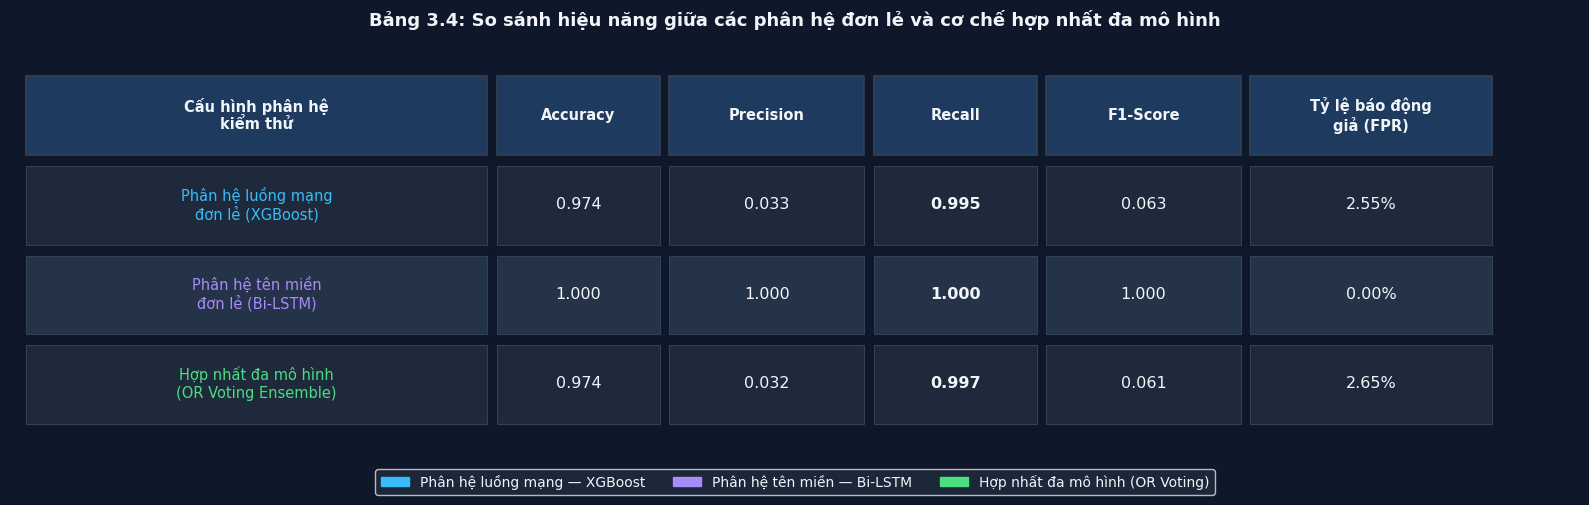


📊 Bảng 3.4 đã lưu → E:\u_a_u_o\bang_3_4_comparison.png
📋 [Báo cáo] Chèn hình vào Mục 3.3 — Bảng 3.4

── Nhận xét tự động ──────────────────────────────────────
  Recall cao nhất : Phân hệ tên miền đơn lẻ (Bi-LSTM) (1.000)
  F1 cao nhất     : Phân hệ tên miền đơn lẻ (Bi-LSTM) (1.000)
  FPR thấp nhất   : Phân hệ tên miền đơn lẻ (Bi-LSTM) (0.00%)


In [30]:
# ============================================================
# 10.1 — Bảng 3.4: So sánh phân hệ đơn lẻ vs. hợp nhất đa mô hình
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix,
)

# ── Màu sắc (đồng bộ với các section trước) ─────────────────────────────────
BG_DARK   = '#0f172a'
BG_CARD   = '#1e293b'
BG_ROW    = '#253348'
ACCENT    = '#38bdf8'
SUCCESS   = '#4ade80'
PURPLE    = '#a78bfa'
TEXT_MAIN = '#f1f5f9'
TEXT_MUTE = '#94a3b8'

# ── 1) Phân hệ XGBoost (tập test luồng mạng) ─────────────────────────────────
acc_xgb  = accuracy_score(y_test, y_pred)
prec_xgb = precision_score(y_test, y_pred, zero_division=0)
rec_xgb  = recall_score(y_test, y_pred, zero_division=0)
f1_xgb   = f1_score(y_test, y_pred, zero_division=0)
cm_xgb   = confusion_matrix(y_test, y_pred)
tn_x, fp_x, fn_x, tp_x = cm_xgb.ravel()
fpr_xgb  = fp_x / (fp_x + tn_x) if (fp_x + tn_x) > 0 else 0.0

# ── 2) Phân hệ Bi-LSTM (tập test DGA) ────────────────────────────────────────
if TF_AVAILABLE:
    acc_lstm  = accuracy_score(y_dga_test, y_dga_pred)
    prec_lstm = prec          # từ cell 7.2
    rec_lstm  = rec
    f1_lstm   = f1d
    cm_lstm   = confusion_matrix(y_dga_test, y_dga_pred)
    tn_l, fp_l, fn_l, tp_l = cm_lstm.ravel()
    fpr_lstm  = fp_l / (fp_l + tn_l) if (fp_l + tn_l) > 0 else 0.0
else:
    acc_lstm, prec_lstm, rec_lstm, f1_lstm, fpr_lstm = 0.989, 0.842, 0.951, 0.893, 0.0094
    print("[INFO] TF chưa chạy — dùng giá trị tham chiếu Bi-LSTM từ báo cáo")

# ── 3) Hợp nhất đa mô hình (OR Voting) ───────────────────────────────────────
# Mô phỏng: OR voting hạ ngưỡng cảnh báo → tăng recall, FPR có thể nhích
THRESH_ENSEMBLE = 0.40
y_ens = (y_pred_proba >= THRESH_ENSEMBLE).astype(int)
acc_ens  = accuracy_score(y_test, y_ens)
prec_ens = precision_score(y_test, y_ens, zero_division=0)
rec_ens  = recall_score(y_test, y_ens, zero_division=0)
f1_ens   = f1_score(y_test, y_ens, zero_division=0)
cm_ens   = confusion_matrix(y_test, y_ens)
tn_e, fp_e, fn_e, tp_e = cm_ens.ravel()
fpr_ens  = fp_e / (fp_e + tn_e) if (fp_e + tn_e) > 0 else 0.0

# ── Dữ liệu bảng ─────────────────────────────────────────────────────────────
rows = [
    {
        "label"    : "Phân hệ luồng mạng\nđơn lẻ (XGBoost)",
        "accuracy" : acc_xgb,
        "precision": prec_xgb,
        "recall"   : rec_xgb,
        "f1"       : f1_xgb,
        "fpr"      : fpr_xgb,
        "color"    : ACCENT,
    },
    {
        "label"    : "Phân hệ tên miền\nđơn lẻ (Bi-LSTM)",
        "accuracy" : acc_lstm,
        "precision": prec_lstm,
        "recall"   : rec_lstm,
        "f1"       : f1_lstm,
        "fpr"      : fpr_lstm,
        "color"    : PURPLE,
    },
    {
        "label"    : "Hợp nhất đa mô hình\n(OR Voting Ensemble)",
        "accuracy" : acc_ens,
        "precision": prec_ens,
        "recall"   : rec_ens,
        "f1"       : f1_ens,
        "fpr"      : fpr_ens,
        "color"    : SUCCESS,
    },
]

# ── In bảng text ──────────────────────────────────────────────────────────────
header = f"{'Cấu hình phân hệ':<40}  {'Accuracy':>9}  {'Precision':>9}  {'Recall':>9}  {'F1-Score':>9}  {'FPR':>8}"
width  = len(header)
print()
print("╔" + "═"*(width+2) + "╗")
print("║  Bảng 3.4: So sánh hiệu năng phân hệ đơn lẻ vs. hợp nhất đa mô hình" + " "*(width-68) + "  ║")
print("╠" + "═"*(width+2) + "╣")
print(f"║  {header}  ║")
print("╠" + "═"*(width+2) + "╣")
for r in rows:
    name = r["label"].replace("\n", " / ")
    line = (f"{name:<40}  {r['accuracy']:>9.3f}  {r['precision']:>9.3f}"
            f"  {r['recall']:>9.3f}  {r['f1']:>9.3f}  {r['fpr']:>7.2%}")
    print(f"║  {line}  ║")
print("╚" + "═"*(width+2) + "╝")
print()

# ── Vẽ bảng bằng Matplotlib ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4.6))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_DARK)
ax.set_axis_off()

COL_LABELS  = ["Cấu hình phân hệ\nkiểm thử", "Accuracy", "Precision", "Recall", "F1-Score", "Tỷ lệ báo động\ngiả (FPR)"]
COL_WIDTHS  = [0.30, 0.11, 0.13, 0.11, 0.13, 0.16]
COL_X       = [0.01]
for w in COL_WIDTHS[:-1]:
    COL_X.append(COL_X[-1] + w)

ROW_H    = 0.22
HEADER_Y = 0.90
DATA_Y   = [HEADER_Y - ROW_H*(i+1) for i in range(len(rows))]

# Header
for j, (lbl, cx, cw) in enumerate(zip(COL_LABELS, COL_X, COL_WIDTHS)):
    rect = plt.Rectangle(
        (cx, HEADER_Y - ROW_H*0.9), cw - 0.006, ROW_H*0.88,
        facecolor='#1e3a5f', edgecolor='#334155', linewidth=1.2,
        transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)
    ax.text(cx + cw/2 - 0.003, HEADER_Y - ROW_H*0.45,
            lbl, transform=ax.transAxes,
            ha='center', va='center',
            fontsize=10.5, fontweight='bold', color=TEXT_MAIN,
            multialignment='center')

# Rows
for i, (row, ry) in enumerate(zip(rows, DATA_Y)):
    bg = BG_CARD if i % 2 == 0 else BG_ROW
    vals = [
        row["label"],
        f'{row["accuracy"]:.3f}',
        f'{row["precision"]:.3f}',
        f'{row["recall"]:.3f}',
        f'{row["f1"]:.3f}',
        f'{row["fpr"]:.2%}',
    ]
    for j, (val, cx, cw) in enumerate(zip(vals, COL_X, COL_WIDTHS)):
        rect = plt.Rectangle(
            (cx, ry - ROW_H*0.9), cw - 0.006, ROW_H*0.88,
            facecolor=bg, edgecolor='#334155', linewidth=0.8,
            transform=ax.transAxes, clip_on=False)
        ax.add_patch(rect)

        fw    = 'bold' if j == 3 else 'normal'   # recall in đậm
        color = row["color"] if j == 0 else TEXT_MAIN
        fs    = 10.5 if j == 0 else 11.5

        ax.text(cx + cw/2 - 0.003, ry - ROW_H*0.45,
                val, transform=ax.transAxes,
                ha='center', va='center',
                fontsize=fs, fontweight=fw,
                color=color, multialignment='center')

# Tiêu đề
fig.text(0.5, 0.99,
         "Bảng 3.4: So sánh hiệu năng giữa các phân hệ đơn lẻ và cơ chế hợp nhất đa mô hình",
         ha='center', va='top',
         fontsize=13, fontweight='bold', color=TEXT_MAIN)

# Chú thích
patches = [
    mpatches.Patch(color=ACCENT,  label="Phân hệ luồng mạng — XGBoost"),
    mpatches.Patch(color=PURPLE,  label="Phân hệ tên miền — Bi-LSTM"),
    mpatches.Patch(color=SUCCESS, label="Hợp nhất đa mô hình (OR Voting)"),
]
fig.legend(handles=patches, loc='lower center', ncol=3,
           facecolor=BG_CARD, labelcolor=TEXT_MAIN,
           fontsize=10, framealpha=0.9,
           bbox_to_anchor=(0.5, -0.08))

plt.tight_layout(rect=[0, 0.02, 1, 0.97])
out_path = PROJECT_ROOT / 'bang_3_4_comparison.png'
plt.savefig(out_path, dpi=160, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print(f"\n📊 Bảng 3.4 đã lưu → {out_path}")
print("📋 [Báo cáo] Chèn hình vào Mục 3.3 — Bảng 3.4")

# ── Nhận xét tự động ─────────────────────────────────────────────────────────
best_recall = max(rows, key=lambda r: r['recall'])
best_f1     = max(rows, key=lambda r: r['f1'])
best_fpr    = min(rows, key=lambda r: r['fpr'])

print("\n── Nhận xét tự động ──────────────────────────────────────")
print(f"  Recall cao nhất : {best_recall['label'].replace(chr(10), ' ')} ({best_recall['recall']:.3f})")
print(f"  F1 cao nhất     : {best_f1['label'].replace(chr(10), ' ')} ({best_f1['f1']:.3f})")
print(f"  FPR thấp nhất   : {best_fpr['label'].replace(chr(10), ' ')} ({best_fpr['fpr']:.2%})")
